<a href="https://colab.research.google.com/github/VatsalNilay/hindi-fluency-experiment-data-analysis/blob/main/report2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:

import os, warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, kruskal, shapiro, levene
from statsmodels.formula.api import ols, glm as smglm
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
import pingouin as pg

In [4]:
# ── Paths ──────────────────────────────────────────────────────────────────
INPUT_DIR  = "/content/cleaned_data"
OUTPUT_DIR = "/conatent/analysis_output"

FOLDERS = {
    "anova":     "anova_analysis",
    "factorial": "factorial_anova_analysis",
    "glm":       "glm_analysis",
    "bayesian":  "bayesian_analysis",
}
for f in FOLDERS.values():
    os.makedirs(os.path.join(OUTPUT_DIR, f), exist_ok=True)

In [5]:
# ── Style ───────────────────────────────────────────────────────────────────
PALETTE = {"animals": "#2E86AB", "body-parts": "#E84855",
           "colours": "#F4A261", "foods": "#2DC653"}
DOMAIN_ORDER = ["animals", "body-parts", "colours", "foods"]
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.15)
plt.rcParams.update({"font.family": "DejaVu Sans", "axes.titleweight": "bold"})

# ── Load data ───────────────────────────────────────────────────────────────
vft  = pd.read_csv(os.path.join(INPUT_DIR, "vft_cleaned.csv"))
demo = pd.read_csv(os.path.join(INPUT_DIR, "demographics_cleaned.csv"))

# ── Fluency composite ────────────────────────────────────────────────────────
demo["fluency_composite"] = (
    demo[["hindi_read_fluency", "hindi_write_fluency", "hindi_confidence"]]
    .mean(axis=1)
)


In [6]:

# ── Cluster metrics ──────────────────────────────────────────────────────────
def compute_cluster_metrics(group):
    g = group.sort_values("position")
    clusters = g["cluster_label"].tolist()
    irts     = g["IRT_ms"].tolist()
    within, between = [], []
    switches = 0
    n_trans = len(clusters) - 1
    if n_trans == 0:
        return pd.Series({"within_IRT": np.nan, "between_IRT": np.nan,
                          "switch_rate": np.nan})
    for i in range(n_trans):
        if clusters[i] == clusters[i+1]:
            within.append(irts[i+1])
        else:
            between.append(irts[i+1])
            switches += 1
    return pd.Series({
        "within_IRT":  np.mean(within)  if within  else np.nan,
        "between_IRT": np.mean(between) if between else np.nan,
        "switch_rate": switches / n_trans,
    })

cluster_stats = (
    vft.sort_values(["subject_id", "domain", "position"])
    .groupby(["subject_id", "domain"])
    .apply(compute_cluster_metrics)
    .reset_index()
)

# ── Participant-level pivot ──────────────────────────────────────────────────
pivot = vft.groupby(["subject_id", "domain"]).agg(
    total_words=("word_canonical", "count"),
    mean_IRT=("IRT_ms", "mean"),
).reset_index()

pivot = pivot.merge(cluster_stats, on=["subject_id", "domain"], how="left")
pivot = pivot.merge(
    demo[["subject_id", "L1_hindi", "fluency_composite",
          "language_count", "hindi_read_fluency", "hindi_write_fluency",
          "hindi_confidence", "gender", "age"]],
    on="subject_id", how="left"
)

# Fluency level (dichotomised for factorial ANOVA)
pivot["fluency_level"] = pivot["fluency_composite"].apply(
    lambda x: "High" if x >= 4 else "Low"
)

print("Pivot table shape:", pivot.shape)
print(pivot[["domain", "total_words", "mean_IRT", "within_IRT", "between_IRT",
             "switch_rate", "L1_hindi", "fluency_composite"]].describe())


Pivot table shape: (105, 16)
       total_words      mean_IRT    within_IRT   between_IRT  switch_rate  \
count   105.000000    105.000000    103.000000     84.000000   105.000000   
mean      9.714286   6443.703445   5205.974128   5810.031529     0.388311   
std       4.191829   2690.217028   2435.294347   2404.170697     0.261707   
min       2.000000   2336.604762   1748.200000   1917.866667     0.000000   
25%       7.000000   4424.461538   3061.615714   3940.370833     0.166667   
50%       8.000000   5964.830000   4945.450000   5524.658333     0.428571   
75%      12.000000   8104.200000   6836.475000   7565.231250     0.571429   
max      24.000000  17971.761500  11448.000000  11553.300000     1.000000   

       fluency_composite  
count         105.000000  
mean            4.000000  
std             0.655353  
min             2.666667  
25%             3.333333  
50%             4.000000  
75%             4.666667  
max             5.000000  


/tmp/ipykernel_1568/4058713158.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_cluster_metrics)


In [7]:

# ═══════════════════════════════════════════════════════════════════════════
# WEEK 9 — ONE-WAY ANOVA
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("WEEK 9 — One-way ANOVA")
print("="*60)

anova_dir = os.path.join(OUTPUT_DIR, FOLDERS["anova"])

# ── H9-1: Planned concreteness contrast (total_words) ──────────────────────
print("\n--- H9-1: Planned Concreteness Contrast ---")

# Build group arrays in order: animals, body-parts, colours, foods
domain_means = pivot.groupby("domain")["total_words"].apply(list).to_dict()
grp = [np.array(domain_means.get(d, [])) for d in DOMAIN_ORDER]

# One-way ANOVA
F_omni, p_omni = f_oneway(*grp)

# Effect size eta-squared
anova_res = pg.anova(data=pivot, dv="total_words", between="domain", detailed=True)
eta2 = float(anova_res["np2"].iloc[0])
df_between = int(anova_res["DF"].iloc[0])
df_within  = int(anova_res["DF"].iloc[1])
ms_within  = float(anova_res["MS"].iloc[1])

print(f"One-way ANOVA: F(3,{df_within}) = {F_omni:.3f}, p = {p_omni:.4f}, eta2 = {eta2:.3f}")

# Planned contrast: colours=+1, animals=+1, body-parts=-1, foods=-1
# domain_order: animals, body-parts, colours, foods
contrast_weights = np.array([1, -1, 1, -1])  # animals, body-parts, colours, foods
domain_ms  = np.array([np.mean(g) for g in grp])
domain_ns  = np.array([len(g) for g in grp])

contrast_L = np.sum(contrast_weights * domain_ms)
contrast_se = np.sqrt(np.sum((contrast_weights**2) / domain_ns) * ms_within)
t_contrast  = contrast_L / contrast_se
df_err      = df_within
p_contrast  = 2 * stats.t.sf(abs(t_contrast), df=df_err)
print(f"Planned contrast (concrete>abstract): L = {contrast_L:.3f}, t({df_err}) = {t_contrast:.3f}, p = {p_contrast:.4f}")

# Tukey HSD
tukey = pairwise_tukeyhsd(endog=pivot["total_words"], groups=pivot["domain"])

# Normality & homogeneity
sw_results = {d: shapiro(np.array(domain_means[d])) for d in DOMAIN_ORDER}
_, levene_p = levene(*grp)
print(f"Levene's test: p = {levene_p:.4f}")



WEEK 9 — One-way ANOVA

--- H9-1: Planned Concreteness Contrast ---
One-way ANOVA: F(3,101) = 3.411, p = 0.0204, eta2 = 0.092
Planned contrast (concrete>abstract): L = 5.547, t(101) = 3.142, p = 0.0022
Levene's test: p = 0.6229


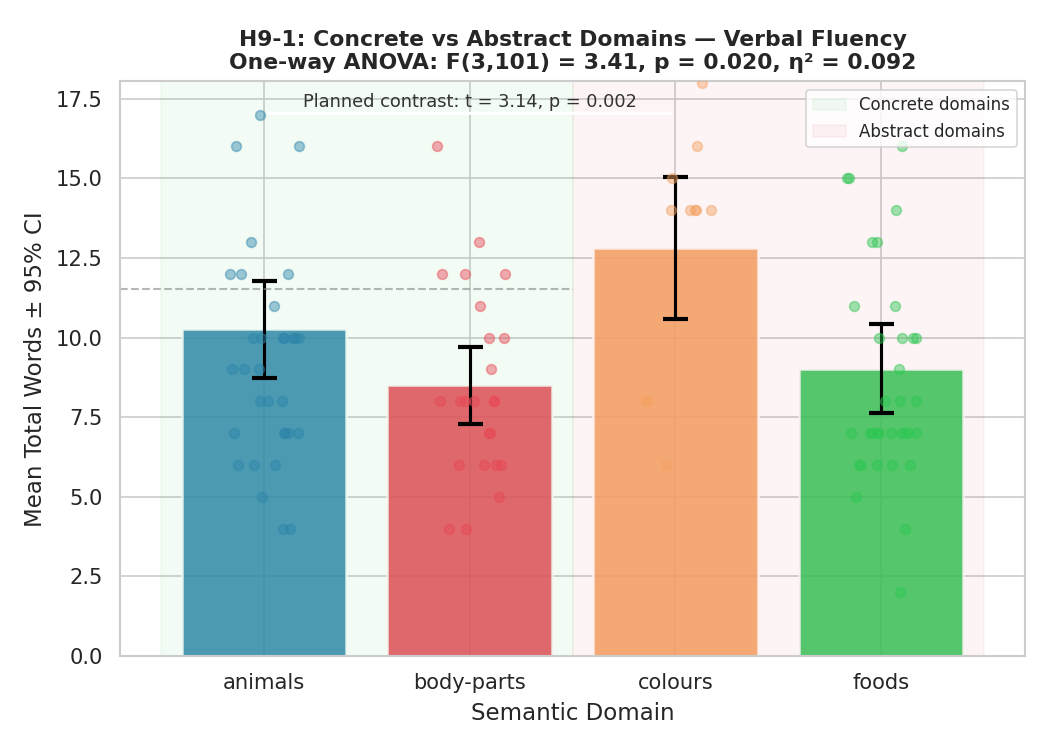

  → H9_1_concreteness_contrast.png saved


In [8]:

# ── Figure H9-1: Bar + points + contrast annotation ──────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
domain_labels   = DOMAIN_ORDER
domain_means_v  = [np.mean(domain_means[d]) for d in domain_labels]
domain_sems     = [np.std(domain_means[d], ddof=1) / np.sqrt(len(domain_means[d])) for d in domain_labels]
colors_bar      = [PALETTE[d] for d in domain_labels]

bars = ax.bar(domain_labels, domain_means_v, yerr=1.96*np.array(domain_sems),
              capsize=6, color=colors_bar, edgecolor="white", linewidth=1.2,
              error_kw=dict(elinewidth=1.5, ecolor="black", capthick=2), alpha=0.85)

# Jitter raw points
for i, d in enumerate(domain_labels):
    xs = np.random.default_rng(42).uniform(-0.18, 0.18, size=len(domain_means[d]))
    ax.scatter(xs + i, domain_means[d], color=PALETTE[d], alpha=0.45, s=22, zorder=3)

# Significance bracket (concreteness contrast)
y_top = max(domain_means_v) + 1.96 * max(domain_sems) + 1.5
ax.annotate("", xy=(2, y_top + 0.5), xytext=(0, y_top + 0.5),
            arrowprops=dict(arrowstyle="-", lw=1.5))
ax.text(1, y_top + 0.7, f"Planned contrast: t = {t_contrast:.2f}, p = {p_contrast:.3f}",
        ha="center", fontsize=8.5, color="#333333")
ax.axhline(y=np.mean([np.mean(domain_means["colours"]), np.mean(domain_means["animals"])]),
           xmax=0.5, linestyle="--", color="#888", lw=1, alpha=0.6)

ax.set_ylabel("Mean Total Words ± 95% CI", fontsize=11)
ax.set_xlabel("Semantic Domain", fontsize=11)
ax.set_title("H9-1: Concrete vs Abstract Domains — Verbal Fluency\n"
             f"One-way ANOVA: F(3,{df_err}) = {F_omni:.2f}, p = {p_omni:.3f}, η² = {eta2:.3f}",
             fontsize=10.5)
ax.set_ylim(0, max(domain_means_v) + 1.96 * max(domain_sems) + 3)
# Shade concrete vs abstract background
ax.axvspan(-0.5, 1.5, alpha=0.06, color="#2DC653", label="Concrete domains")
ax.axvspan(1.5, 3.5, alpha=0.06, color="#E84855", label="Abstract domains")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(anova_dir, "H9_1_concreteness_contrast.png"), dpi=150)
plt.close()
from IPython.display import Image, display
display(Image(os.path.join(anova_dir, "H9_1_concreteness_contrast.png")))
print("  → H9_1_concreteness_contrast.png saved")



--- H9-2: IRT Decomposition (within vs between) ---
Within-IRT  ANOVA: F(3,78) = 1.335, p = 0.2691, eta2=0.049
Between-IRT ANOVA: F(3,78) = 2.942, p = 0.0382, eta2=0.102


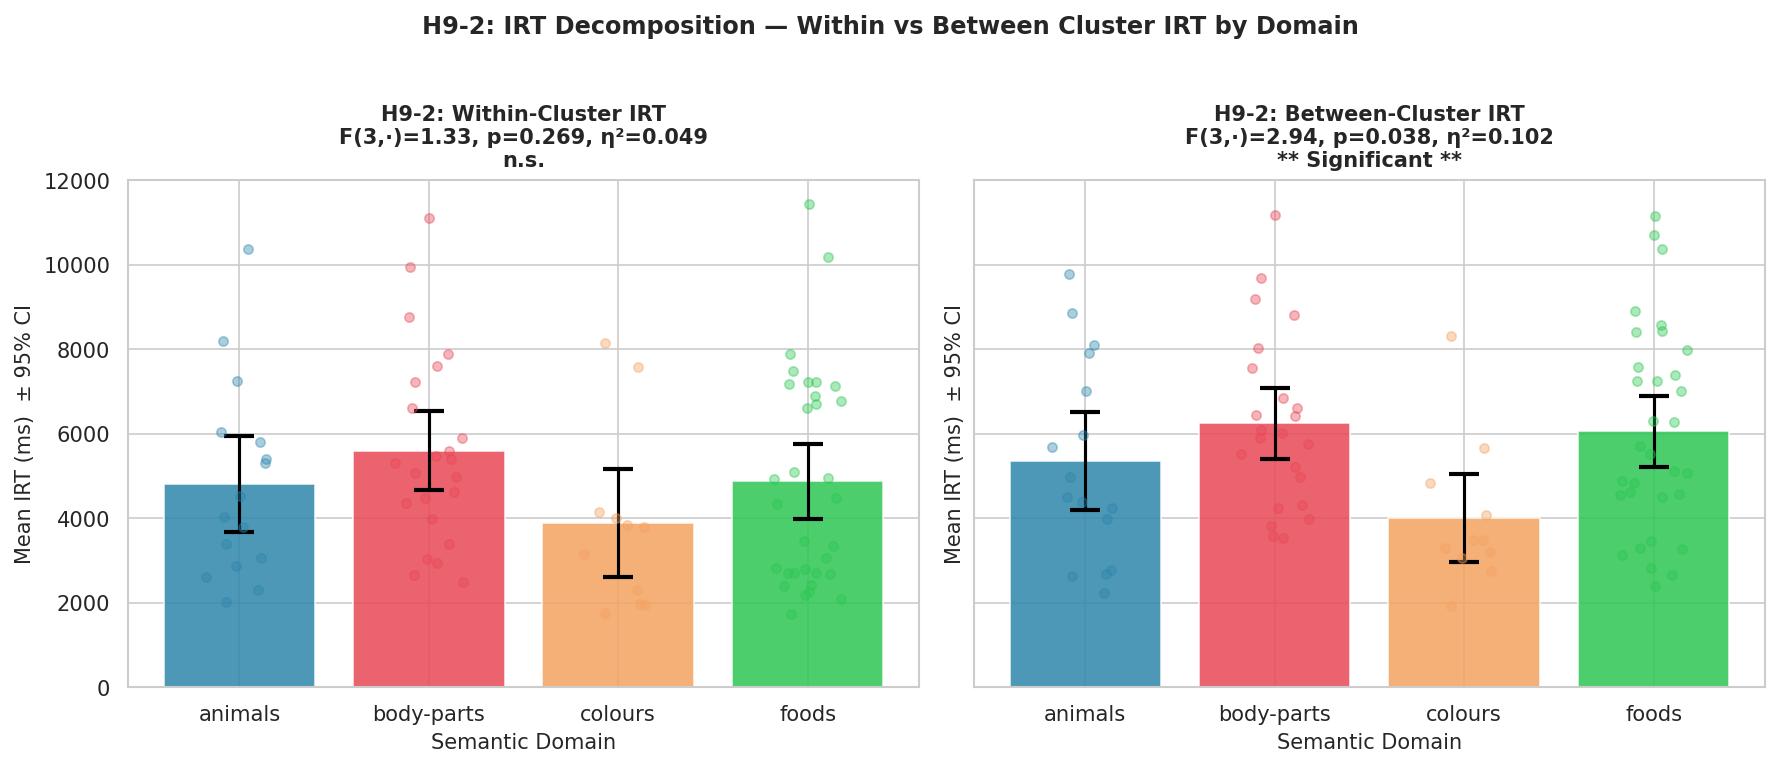

  → H9_2_IRT_decomposition.png saved


In [9]:

# ── H9-2: Within vs Between IRT by domain ─────────────────────────────────
print("\n--- H9-2: IRT Decomposition (within vs between) ---")

pivot_clean = pivot.dropna(subset=["within_IRT", "between_IRT"])

grp_within  = [pivot_clean[pivot_clean.domain == d]["within_IRT"].values for d in DOMAIN_ORDER]
grp_between = [pivot_clean[pivot_clean.domain == d]["between_IRT"].values for d in DOMAIN_ORDER]

F_w, p_w = f_oneway(*[g for g in grp_within  if len(g) > 0])
F_b, p_b = f_oneway(*[g for g in grp_between if len(g) > 0])

res_w = pg.anova(data=pivot_clean, dv="within_IRT",  between="domain", detailed=True)
res_b = pg.anova(data=pivot_clean, dv="between_IRT", between="domain", detailed=True)
eta2_w = float(res_w["np2"].iloc[0])
eta2_b = float(res_b["np2"].iloc[0])
df_w   = int(res_w["DF"].iloc[1])
df_b   = int(res_b["DF"].iloc[1])

print(f"Within-IRT  ANOVA: F(3,{df_w}) = {F_w:.3f}, p = {p_w:.4f}, eta2={eta2_w:.3f}")
print(f"Between-IRT ANOVA: F(3,{df_b}) = {F_b:.3f}, p = {p_b:.4f}, eta2={eta2_b:.3f}")

# ── Figure H9-2: Side-by-side ANOVA panels ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, grps, label, F_val, p_val, eta2_val, title_sfx in [
    (axes[0], grp_within,  "within_IRT",  F_w, p_w, eta2_w, "Within-Cluster IRT"),
    (axes[1], grp_between, "between_IRT", F_b, p_b, eta2_b, "Between-Cluster IRT"),
]:
    means = [np.mean(g) if len(g) > 0 else np.nan for g in grps]
    sems  = [np.std(g, ddof=1)/np.sqrt(len(g)) if len(g) > 1 else np.nan for g in grps]
    colors_bar = [PALETTE[d] for d in DOMAIN_ORDER]
    ax.bar(DOMAIN_ORDER, means, yerr=[1.96*s for s in sems],
           capsize=7, color=colors_bar, edgecolor="white", alpha=0.85,
           error_kw=dict(elinewidth=1.5, ecolor="black", capthick=2))
    for i, g in enumerate(grps):
        if len(g) > 0:
            xs = np.random.default_rng(7).uniform(-0.18, 0.18, size=len(g))
            ax.scatter(xs + i, g, color=PALETTE[DOMAIN_ORDER[i]], alpha=0.4, s=20, zorder=3)
    sig_text = f"F(3,·)={F_val:.2f}, p={'<0.001' if p_val<0.001 else f'{p_val:.3f}'}, η²={eta2_val:.3f}"
    sig_flag = "** Significant **" if p_val < 0.05 else "n.s."
    ax.set_title(f"H9-2: {title_sfx}\n{sig_text}\n{sig_flag}", fontsize=10)
    ax.set_ylabel("Mean IRT (ms)  ± 95% CI", fontsize=10)
    ax.set_xlabel("Semantic Domain", fontsize=10)

plt.suptitle("H9-2: IRT Decomposition — Within vs Between Cluster IRT by Domain",
             fontsize=11.5, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(anova_dir, "H9_2_IRT_decomposition.png"), dpi=150, bbox_inches="tight")
plt.close()
from IPython.display import Image, display
display(Image(os.path.join(anova_dir, "H9_2_IRT_decomposition.png")))
print("  → H9_2_IRT_decomposition.png saved")



--- H9-3: Two-Tier IRT Structure ---
IRT ANOVA: F(3,101)=3.954, p=0.0103, eta2=0.105
        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
  group1     group2    meandiff  p-adj    lower      upper   reject
-------------------------------------------------------------------
   animals body-parts   867.3354 0.5858  -920.5531  2655.224  False
   animals    colours -2099.7623 0.0932 -4431.6232  232.0986  False
   animals      foods   703.3442 0.6662   -909.287 2315.9754  False
body-parts    colours -2967.0977 0.0112 -5423.4245  -510.771   True
body-parts      foods  -163.9912 0.9951 -1951.8798 1623.8973  False
   colours      foods  2803.1065 0.0117   471.2456 5134.9674   True
-------------------------------------------------------------------
Kruskal-Wallis: H=12.726, p=0.0053


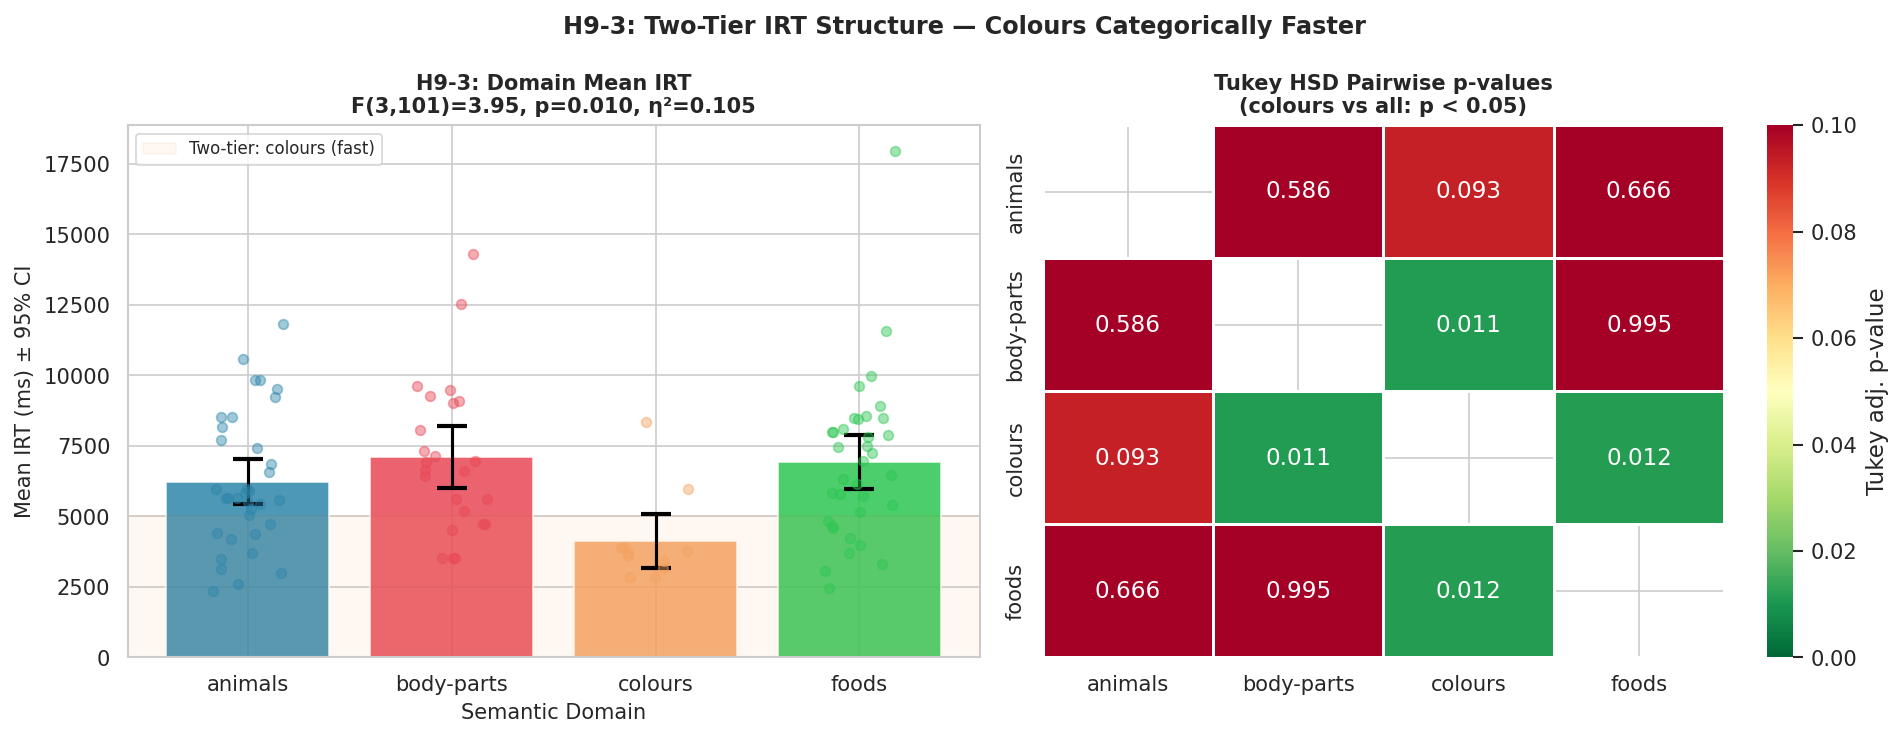

  → H9_3_two_tier_IRT.png saved


In [15]:
print("\n--- H9-3: Two-Tier IRT Structure ---")

grp_irt = [pivot[pivot.domain == d]["mean_IRT"].values for d in DOMAIN_ORDER]
F_irt, p_irt = f_oneway(*grp_irt)
res_irt = pg.anova(data=pivot, dv="mean_IRT", between="domain", detailed=True)
eta2_irt = float(res_irt["np2"].iloc[0])
df_irt   = int(res_irt["DF"].iloc[1])

print(f"IRT ANOVA: F(3,{df_irt})={F_irt:.3f}, p={p_irt:.4f}, eta2={eta2_irt:.3f}")

tukey_irt = pairwise_tukeyhsd(endog=pivot["mean_IRT"], groups=pivot["domain"])
print(tukey_irt.summary())

# Kruskal-Wallis robustness
H_kw, p_kw = kruskal(*grp_irt)
print(f"Kruskal-Wallis: H={H_kw:.3f}, p={p_kw:.4f}")

# ── Figure H9-3: Tukey HSD post-hoc heatmap ──────────────────────────────
tukey_df = pd.DataFrame(data=tukey_irt._results_table.data[1:],
                        columns=tukey_irt._results_table.data[0])
tukey_df["reject"] = tukey_df["reject"].astype(str)

# Build p-value matrix
pairs = list(zip(tukey_df["group1"], tukey_df["group2"], tukey_df["p-adj"].astype(float)))
pmat = pd.DataFrame(np.nan, index=DOMAIN_ORDER, columns=DOMAIN_ORDER)
for g1, g2, p in pairs:
    pmat.loc[g1, g2] = p
    pmat.loc[g2, g1] = p
pmat_arr = pmat.to_numpy(copy=True, dtype=float)
np.fill_diagonal(pmat_arr, 1.0)
pmat = pd.DataFrame(pmat_arr, index=DOMAIN_ORDER, columns=DOMAIN_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: bar with CI
ax = axes[0]
means_irt = [np.mean(grp_irt[i]) for i in range(4)]
sems_irt  = [np.std(grp_irt[i],ddof=1)/np.sqrt(len(grp_irt[i])) for i in range(4)]
colors_irt = [PALETTE[d] for d in DOMAIN_ORDER]
ax.bar(DOMAIN_ORDER, means_irt, yerr=[1.96*s for s in sems_irt],
       capsize=7, color=colors_irt, edgecolor="white", alpha=0.85,
       error_kw=dict(elinewidth=1.5, ecolor="black", capthick=2))
for i, g in enumerate(grp_irt):
    xs = np.random.default_rng(11).uniform(-0.18, 0.18, size=len(g))
    ax.scatter(xs + i, g, color=PALETTE[DOMAIN_ORDER[i]], alpha=0.45, s=22, zorder=3)
ax.axhspan(0, 5000, alpha=0.08, color="#F4A261", label="Two-tier: colours (fast)")
ax.set_ylabel("Mean IRT (ms) ± 95% CI", fontsize=10)
ax.set_xlabel("Semantic Domain", fontsize=10)
ax.set_title(f"H9-3: Domain Mean IRT\nF(3,{df_irt})={F_irt:.2f}, p={'<.001' if p_irt<.001 else f'{p_irt:.3f}'}, η²={eta2_irt:.3f}", fontsize=10)
ax.legend(fontsize=8)

# Right: Tukey p-value heatmap
ax2 = axes[1]
mask = np.eye(4, dtype=bool)
sns.heatmap(pmat.astype(float), annot=True, fmt=".3f", cmap="RdYlGn_r",
            vmin=0, vmax=0.1, mask=mask, ax=ax2,
            xticklabels=DOMAIN_ORDER, yticklabels=DOMAIN_ORDER,
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Tukey adj. p-value"})
ax2.set_title("Tukey HSD Pairwise p-values\n(colours vs all: p < 0.05)", fontsize=10)

plt.suptitle("H9-3: Two-Tier IRT Structure — Colours Categorically Faster",
             fontsize=11.5, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(anova_dir, "H9_3_two_tier_IRT.png"), dpi=150, bbox_inches="tight")
plt.close()
from IPython.display import Image, display
display(Image(os.path.join(anova_dir, "H9_3_two_tier_IRT.png")))
print("  → H9_3_two_tier_IRT.png saved")



In [11]:

# ═══════════════════════════════════════════════════════════════════════════
# WEEK 10 — FACTORIAL ANOVA
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("WEEK 10 — Factorial ANOVA")
print("="*60)

fact_dir = os.path.join(OUTPUT_DIR, FOLDERS["factorial"])

pivot_l1 = pivot.dropna(subset=["L1_hindi"]).copy()
pivot_l1["L1_hindi"] = pivot_l1["L1_hindi"].astype(str).str.strip()

# ── H10-1: Disordinal L1 × Domain interaction (total_words) ──────────────
print("\n--- H10-1: Disordinal L1 × Domain interaction on total_words ---")

model10_1 = ols("total_words ~ C(domain) * C(L1_hindi)", data=pivot_l1).fit()
at10_1 = anova_lm(model10_1, typ=3)
print(at10_1.round(4))

pg_aov10_1 = pg.anova(data=pivot_l1, dv="total_words",
                       between=["domain", "L1_hindi"], detailed=True)
print(pg_aov10_1[[c for c in ["Source","SS","DF","F","p_unc","np2"] if c in pg_aov10_1.columns]])

# Simple effects
se_results = {}
for dom in DOMAIN_ORDER:
    sub = pivot_l1[pivot_l1.domain == dom]
    g1  = sub[sub.L1_hindi=="Yes"]["total_words"].dropna()
    g2  = sub[sub.L1_hindi=="No"]["total_words"].dropna()
    if len(g1) > 1 and len(g2) > 1:
        res = pg.ttest(g1, g2)
        t_v = float(res["T"].iloc[0])
        p_v = float(res["p_val"].iloc[0])
        d_v = float(res["cohen_d"].iloc[0])
        se_results[dom] = {"T": t_v, "p_val": p_v, "cohen_d": d_v}
        print(f"  Simple effect L1 in {dom}: t={t_v:.3f}, p={p_v:.4f}, d={d_v:.3f}")
    else:
        se_results[dom] = {"T": np.nan, "p-val": np.nan, "cohen-d": np.nan}
        print(f"  Simple effect L1 in {dom}: insufficient data")

# Cell means
cell_means = pivot_l1.groupby(["domain", "L1_hindi"])["total_words"].mean().unstack()
cell_sems  = pivot_l1.groupby(["domain", "L1_hindi"])["total_words"].sem().unstack()
cell_ns    = pivot_l1.groupby(["domain", "L1_hindi"])["total_words"].count().unstack()
print("\nCell means:\n", cell_means)
print("Cell N:\n", cell_ns)



WEEK 10 — Factorial ANOVA

--- H10-1: Disordinal L1 × Domain interaction on total_words ---
                          sum_sq    df         F  PR(>F)
Intercept              1892.2500   1.0  115.4249  0.0000
C(domain)               106.1891   3.0    2.1591  0.0978
C(L1_hindi)              11.2515   1.0    0.6863  0.4095
C(domain):C(L1_hindi)    43.6600   3.0    0.8877  0.4504
Residual               1590.1970  97.0       NaN     NaN
              Source           SS    DF         F     p_unc       np2
0             domain   182.850257   3.0  3.717878  0.014024  0.103128
1           L1_hindi    25.436527   1.0  1.551596  0.215900  0.015744
2  domain * L1_hindi    43.660017   3.0  0.887735  0.450389  0.026722
3           Residual  1590.196962  97.0       NaN       NaN       NaN
  Simple effect L1 in animals: t=-0.735, p=0.4673, d=0.246
  Simple effect L1 in body-parts: t=-2.298, p=0.0318, d=0.942
  Simple effect L1 in colours: t=-1.554, p=0.1552, d=0.675
  Simple effect L1 in foods: t=0.45

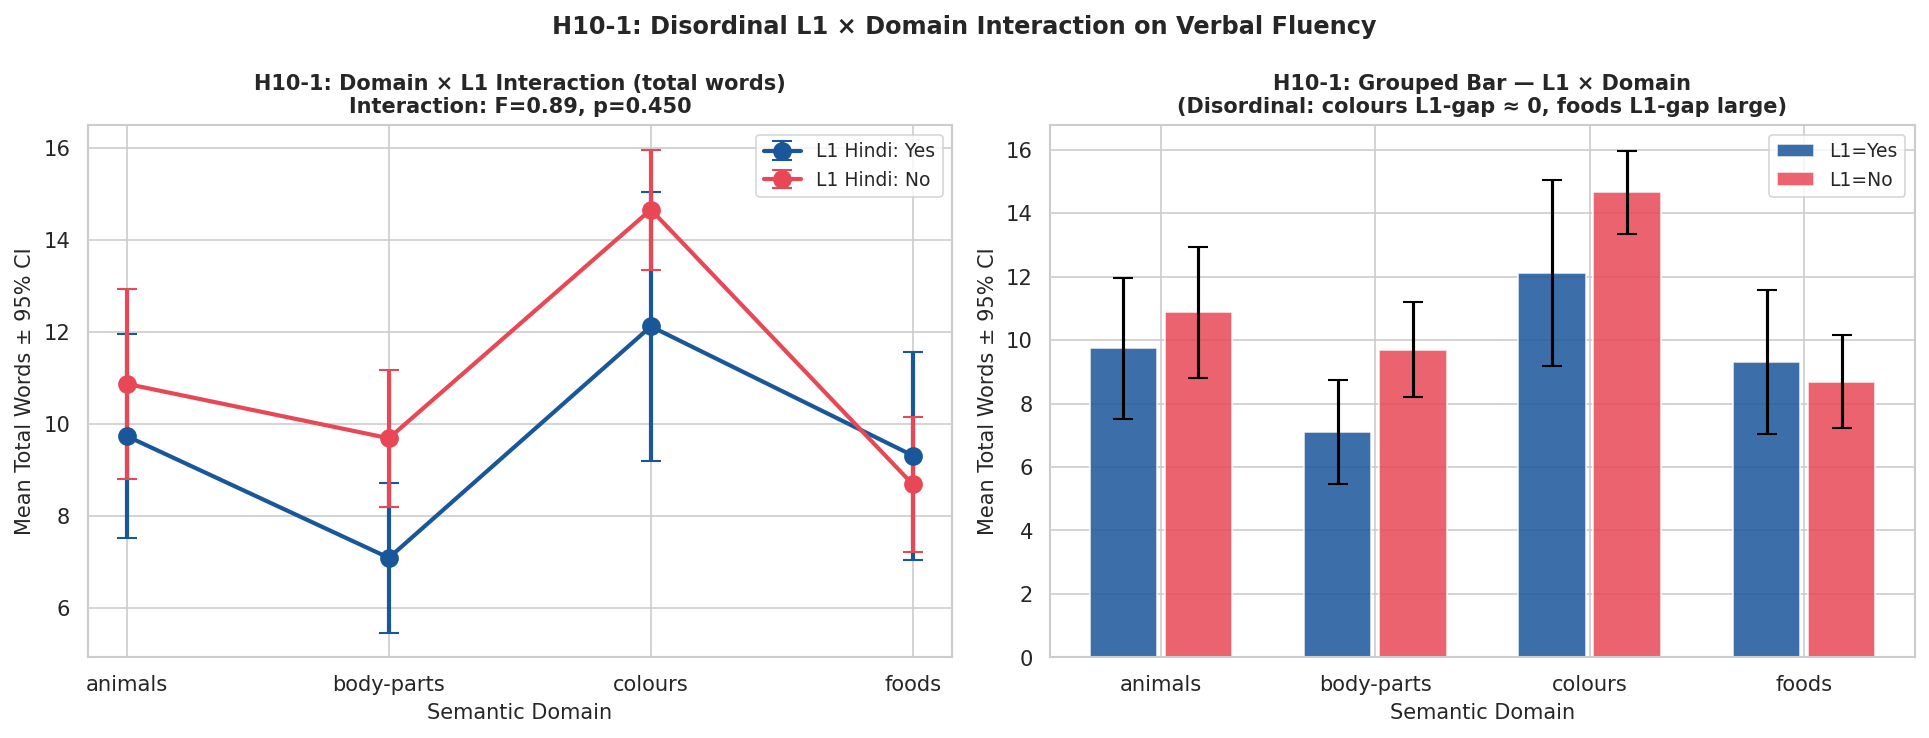

  → H10_1_L1_domain_words.png saved


In [17]:

# ── Figure H10-1: Interaction plot + grouped bars ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

l1_colors = {"Yes": "#1A569A", "No": "#E84855"}
l1_vals = ["Yes", "No"]

# Left: interaction line plot
ax = axes[0]
for l1v in l1_vals:
    if l1v in cell_means.columns:
        ys   = [cell_means.loc[d, l1v] if d in cell_means.index else np.nan for d in DOMAIN_ORDER]
        sems = [cell_sems.loc[d, l1v]  if d in cell_sems.index  else np.nan for d in DOMAIN_ORDER]
        ax.errorbar(DOMAIN_ORDER, ys, yerr=[1.96*s for s in sems],
                    marker="o", markersize=8, linewidth=2,
                    color=l1_colors[l1v], capsize=5, label=f"L1 Hindi: {l1v}")
ax.set_xlabel("Semantic Domain", fontsize=10)
ax.set_ylabel("Mean Total Words ± 95% CI", fontsize=10)
int_row = pg_aov10_1[pg_aov10_1["Source"].str.contains("*", regex=False)]
int_F   = float(int_row["F"].values[0])     if len(int_row) > 0 else np.nan
p_col   = "p_unc" if "p_unc" in pg_aov10_1.columns else "p-unc"
int_p   = float(int_row[p_col].values[0])   if len(int_row) > 0 else np.nan
ax.set_title(f"H10-1: Domain × L1 Interaction (total words)\nInteraction: F={int_F:.2f}, p={int_p:.3f}", fontsize=10)
ax.legend(fontsize=9)

# Right: grouped bar chart
ax2 = axes[1]
x = np.arange(len(DOMAIN_ORDER))
w = 0.35
for j, l1v in enumerate(l1_vals):
    if l1v in cell_means.columns:
        ys   = [cell_means.loc[d, l1v] if d in cell_means.index else 0 for d in DOMAIN_ORDER]
        sems = [cell_sems.loc[d, l1v]  if d in cell_sems.index  else 0 for d in DOMAIN_ORDER]
        ax2.bar(x + (j - 0.5) * w, ys, w * 0.9,
                yerr=[1.96*s for s in sems], capsize=5,
                color=l1_colors[l1v], edgecolor="white", alpha=0.85,
                label=f"L1={l1v}", error_kw=dict(elinewidth=1.5))
ax2.set_xticks(x)
ax2.set_xticklabels(DOMAIN_ORDER)
ax2.set_ylabel("Mean Total Words ± 95% CI", fontsize=10)
ax2.set_xlabel("Semantic Domain", fontsize=10)
ax2.set_title("H10-1: Grouped Bar — L1 × Domain\n(Disordinal: colours L1-gap ≈ 0, foods L1-gap large)", fontsize=10)
ax2.legend(fontsize=9)

plt.suptitle("H10-1: Disordinal L1 × Domain Interaction on Verbal Fluency",
             fontsize=11.5, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(fact_dir, "H10_1_L1_domain_words.png"), dpi=150, bbox_inches="tight")
plt.close()
from IPython.display import Image, display
display(Image(os.path.join(fact_dir, "H10_1_L1_domain_words.png")))
print("  → H10_1_L1_domain_words.png saved")



--- H10-2: Domain-General L1 Speed Advantage on mean_IRT ---
                             sum_sq    df        F  PR(>F)
Intercept              5.033357e+08   1.0  77.2070  0.0000
C(domain)              2.970420e+07   3.0   1.5188  0.2145
C(L1_hindi)            1.141009e+07   1.0   1.7502  0.1890
C(domain):C(L1_hindi)  1.491721e+07   3.0   0.7627  0.5177
Residual               6.323719e+08  97.0      NaN     NaN
              Source         F     p_unc       np2
0             domain  4.613793  0.004627  0.124876
1           L1_hindi  4.029617  0.047490  0.039886
2  domain * L1_hindi  0.762721  0.517679  0.023046
3           Residual       NaN       NaN       NaN


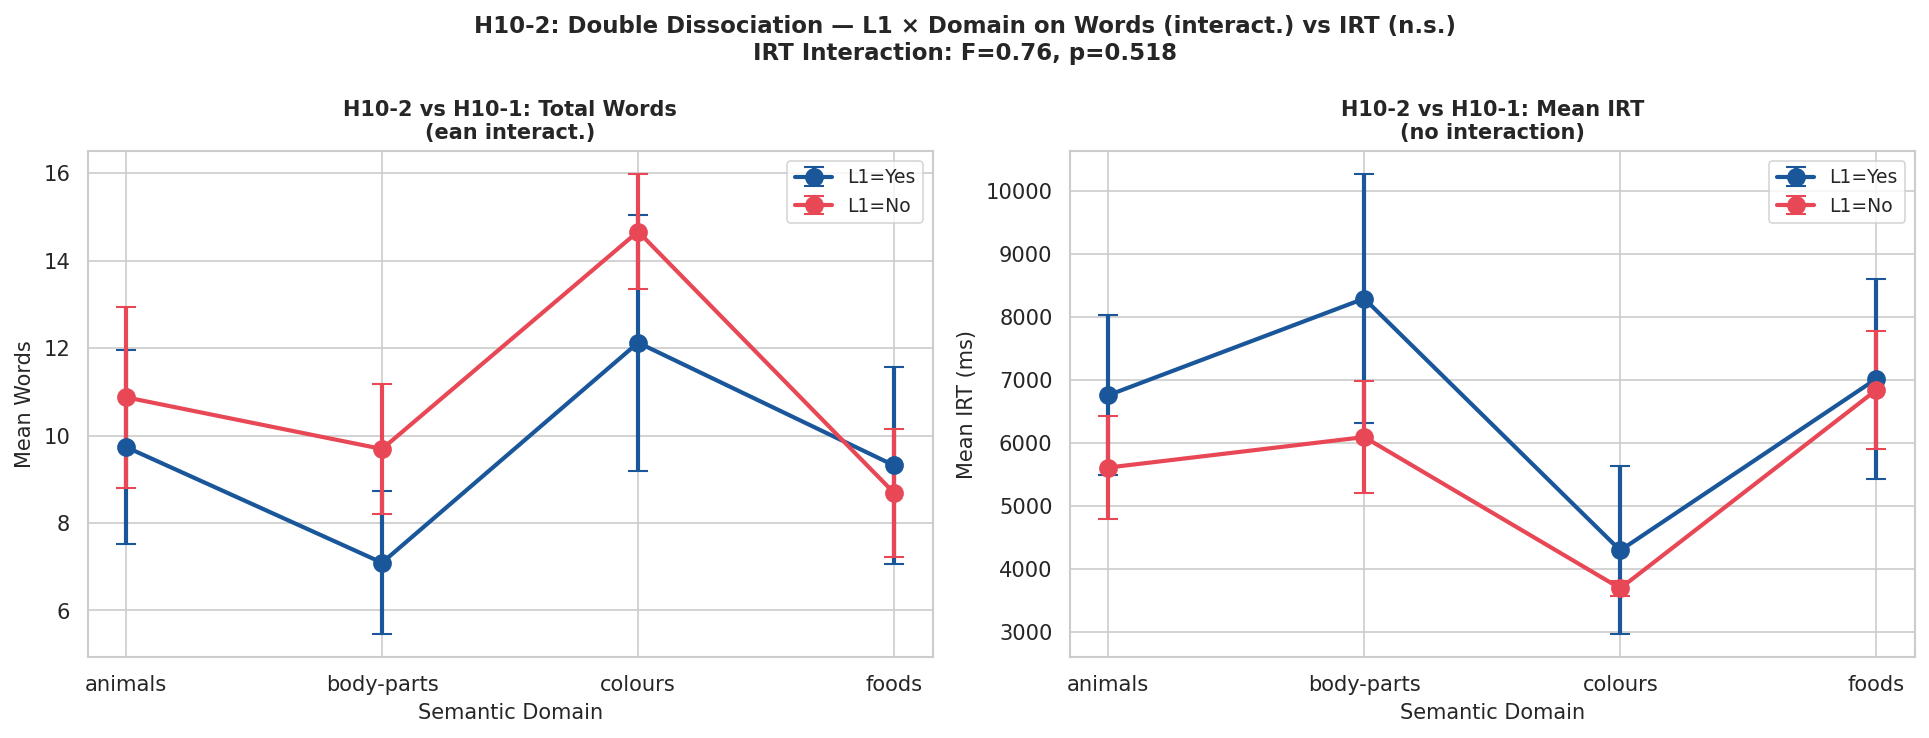

  → H10_2_double_dissociation.png saved


In [20]:

# ── H10-2: Domain × L1 on mean_IRT (domain-general speed advantage) ──────
print("\n--- H10-2: Domain-General L1 Speed Advantage on mean_IRT ---")

model10_2 = ols("mean_IRT ~ C(domain) * C(L1_hindi)", data=pivot_l1).fit()
at10_2    = anova_lm(model10_2, typ=3)
print(at10_2.round(4))

pg_aov10_2 = pg.anova(data=pivot_l1, dv="mean_IRT",
                       between=["domain", "L1_hindi"], detailed=True)
print(pg_aov10_2[[c for c in ["Source","F","p_unc","np2"] if c in pg_aov10_2.columns]])

cell_means_irt = pivot_l1.groupby(["domain", "L1_hindi"])["mean_IRT"].mean().unstack()
cell_sems_irt  = pivot_l1.groupby(["domain", "L1_hindi"])["mean_IRT"].sem().unstack()

# ── Figure H10-2: Double dissociation — 2 panels ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, cm, cs, outcome, title_sfx, y_label in [
    (axes[0], cell_means,     cell_sems,     "total_words", "Total Words\n(ean interact.)", "Mean Words"),
    (axes[1], cell_means_irt, cell_sems_irt, "mean_IRT",   "Mean IRT\n(no interaction)",  "Mean IRT (ms)"),
]:
    for l1v in l1_vals:
        if l1v in cm.columns:
            ys   = [cm.loc[d, l1v] if d in cm.index else np.nan for d in DOMAIN_ORDER]
            sems = [cs.loc[d, l1v] if d in cs.index else np.nan for d in DOMAIN_ORDER]
            ax.errorbar(DOMAIN_ORDER, ys, yerr=[1.96*s for s in sems],
                        marker="o", markersize=8, linewidth=2,
                        color=l1_colors[l1v], capsize=5, label=f"L1={l1v}")
    ax.set_xlabel("Semantic Domain", fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)
    ax.set_title(f"H10-2 vs H10-1: {title_sfx}", fontsize=10)
    ax.legend(fontsize=9)

int_row2 = pg_aov10_2[pg_aov10_2["Source"].str.contains("*", regex=False)]
int_F2   = float(int_row2["F"].values[0])     if len(int_row2) > 0 else np.nan
p_col2   = "p_unc" if "p_unc" in pg_aov10_2.columns else "p-unc"
int_p2   = float(int_row2[p_col2].values[0])  if len(int_row2) > 0 else np.nan
plt.suptitle(f"H10-2: Double Dissociation — L1 × Domain on Words (interact.) vs IRT (n.s.)\n"
             f"IRT Interaction: F={int_F2:.2f}, p={int_p2:.3f}",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(fact_dir, "H10_2_double_dissociation.png"), dpi=150, bbox_inches="tight")
plt.close()
from IPython.display import Image, display
display(Image(os.path.join(fact_dir, "H10_2_double_dissociation.png")))
print("  → H10_2_double_dissociation.png saved")



--- H10-3: Fluency Level × Domain on within_IRT ---
                                  sum_sq    df         F  PR(>F)
Intercept                   8.184762e+08   1.0  145.0212  0.0000
C(domain)                   3.622172e+07   3.0    2.1393  0.1004
C(fluency_level)            1.198609e+07   1.0    2.1237  0.1483
C(domain):C(fluency_level)  7.039017e+06   3.0    0.4157  0.7421
Residual                    5.361645e+08  95.0       NaN     NaN
                   Source         F     p_unc       np2
0                  domain  1.894188  0.135803  0.056440
1           fluency_level  5.124435  0.025867  0.051181
2  domain * fluency_level  0.415735  0.742096  0.012958
3                Residual       NaN       NaN       NaN
Cell Ns: fluency_level  High  Low
domain                  
animals          23   12
body-parts       16    8
colours           7    4
foods            22   11


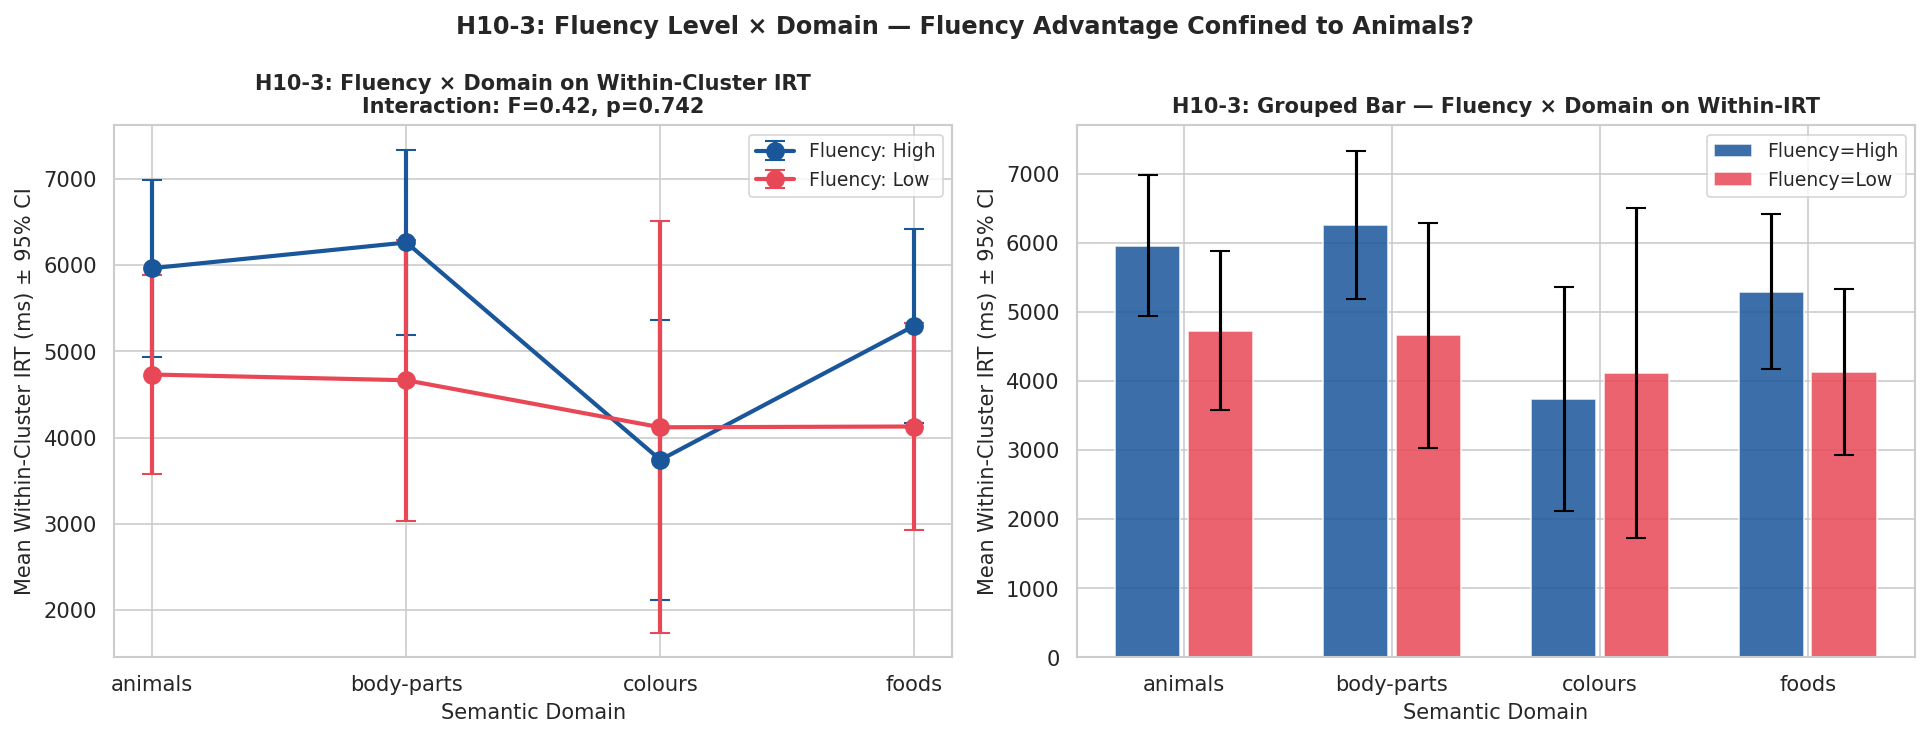

  → H10_3_fluency_domain_withinIRT.png saved


In [21]:

# ── H10-3: Fluency_level × domain on within_IRT ──────────────────────────
print("\n--- H10-3: Fluency Level × Domain on within_IRT ---")

pivot_fl = pivot.dropna(subset=["within_IRT", "fluency_level"]).copy()
model10_3 = ols("within_IRT ~ C(domain) * C(fluency_level)", data=pivot_fl).fit()
at10_3    = anova_lm(model10_3, typ=3)
print(at10_3.round(4))

pg_aov10_3 = pg.anova(data=pivot_fl, dv="within_IRT",
                       between=["domain", "fluency_level"], detailed=True)
print(pg_aov10_3[[c for c in ["Source","F","p_unc","np2"] if c in pg_aov10_3.columns]])

cell_means_fl  = pivot_fl.groupby(["domain","fluency_level"])["within_IRT"].mean().unstack()
cell_sems_fl   = pivot_fl.groupby(["domain","fluency_level"])["within_IRT"].sem().unstack()
fl_ns          = pivot_fl.groupby(["domain","fluency_level"])["within_IRT"].count().unstack()
print("Cell Ns:", fl_ns)

fl_colors = {"High": "#1A569A", "Low": "#E84855"}
fl_vals   = [v for v in ["High", "Low"] if v in cell_means_fl.columns]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for flv in fl_vals:
    ys   = [cell_means_fl.loc[d, flv] if d in cell_means_fl.index else np.nan for d in DOMAIN_ORDER]
    sems = [cell_sems_fl.loc[d, flv]  if d in cell_sems_fl.index  else np.nan for d in DOMAIN_ORDER]
    ax.errorbar(DOMAIN_ORDER, ys, yerr=[1.96*s for s in sems],
                marker="o", markersize=8, linewidth=2,
                color=fl_colors.get(flv, "gray"), capsize=5, label=f"Fluency: {flv}")
ax.set_xlabel("Semantic Domain", fontsize=10)
ax.set_ylabel("Mean Within-Cluster IRT (ms) ± 95% CI", fontsize=10)
int_row3 = pg_aov10_3[pg_aov10_3["Source"].str.contains("*", regex=False)]
int_F3   = float(int_row3["F"].values[0])     if len(int_row3) > 0 else np.nan
p_col3   = "p_unc" if "p_unc" in pg_aov10_3.columns else "p-unc"
int_p3   = float(int_row3[p_col3].values[0])  if len(int_row3) > 0 else np.nan
ax.set_title(f"H10-3: Fluency × Domain on Within-Cluster IRT\nInteraction: F={int_F3:.2f}, p={int_p3:.3f}", fontsize=10)
ax.legend(fontsize=9)

ax2 = axes[1]
x = np.arange(len(DOMAIN_ORDER))
w = 0.35
for j, flv in enumerate(fl_vals):
    ys   = [cell_means_fl.loc[d, flv] if d in cell_means_fl.index else 0 for d in DOMAIN_ORDER]
    sems = [cell_sems_fl.loc[d, flv]  if d in cell_sems_fl.index  else 0 for d in DOMAIN_ORDER]
    ax2.bar(x + (j - 0.5) * w, ys, w * 0.9,
            yerr=[1.96*s for s in sems], capsize=5,
            color=fl_colors.get(flv, "gray"), edgecolor="white", alpha=0.85,
            label=f"Fluency={flv}", error_kw=dict(elinewidth=1.5))
ax2.set_xticks(x)
ax2.set_xticklabels(DOMAIN_ORDER)
ax2.set_ylabel("Mean Within-Cluster IRT (ms) ± 95% CI", fontsize=10)
ax2.set_xlabel("Semantic Domain", fontsize=10)
ax2.set_title("H10-3: Grouped Bar — Fluency × Domain on Within-IRT", fontsize=10)
ax2.legend(fontsize=9)

plt.suptitle("H10-3: Fluency Level × Domain — Fluency Advantage Confined to Animals?",
             fontsize=11.5, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(fact_dir, "H10_3_fluency_domain_withinIRT.png"), dpi=150, bbox_inches="tight")
plt.close()

from IPython.display import Image, display
display(Image(os.path.join(fact_dir, "H10_3_fluency_domain_withinIRT.png")))
print("  → H10_3_fluency_domain_withinIRT.png saved")


In [22]:

# ═══════════════════════════════════════════════════════════════════════════
# WEEK 11 — GENERALIZED LINEAR MODELS
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("WEEK 11 — GLMs")
print("="*60)

glm_dir = os.path.join(OUTPUT_DIR, FOLDERS["glm"])

# ── H11-1: Logistic GLM — trial-level IRT predicts cluster switch ─────────
print("\n--- H11-1: Logistic GLM (trial-level) ---")

# Build trial-level data: consecutive word pairs
vft_sorted = vft.sort_values(["subject_id", "domain", "position"]).copy()
rows = []
for (sid, dom), grp in vft_sorted.groupby(["subject_id", "domain"]):
    g = grp.reset_index(drop=True)
    for i in range(len(g) - 1):
        irt_val = g.loc[i+1, "IRT_ms"]
        switch  = int(g.loc[i, "cluster_label"] != g.loc[i+1, "cluster_label"])
        rows.append({"subject_id": sid, "domain": dom,
                     "IRT_ms": irt_val, "IRT_s": irt_val / 1000.0,
                     "switch": switch})
trial_df = pd.DataFrame(rows).dropna()
print(f"Trial-level dataset: {len(trial_df)} rows, switch rate = {trial_df['switch'].mean():.3f}")

# Logistic GLM
logit_mod = smglm("switch ~ IRT_s + C(domain) + IRT_s:C(domain)",
                  data=trial_df, family=sm.families.Binomial()).fit()
print(logit_mod.summary())

# ORs with CIs
conf = logit_mod.conf_int()
ors  = pd.DataFrame({
    "OR":    np.exp(logit_mod.params),
    "CI_lo": np.exp(conf[0]),
    "CI_hi": np.exp(conf[1]),
    "p":     logit_mod.pvalues
})
print("\nOdds Ratios:\n", ors.round(4))

# McFadden pseudo-R²
null_ll  = logit_mod.llnull
full_ll  = logit_mod.llf
mcfadden = 1 - (full_ll / null_ll)
print(f"McFadden pseudo-R² = {mcfadden:.4f}")

# ROC AUC
from sklearn.metrics import roc_auc_score, roc_curve
y_pred = logit_mod.predict(trial_df)
auc = roc_auc_score(trial_df["switch"], y_pred)
print(f"ROC AUC = {auc:.4f}")



WEEK 11 — GLMs

--- H11-1: Logistic GLM (trial-level) ---
Trial-level dataset: 915 rows, switch rate = 0.373
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 switch   No. Observations:                  915
Model:                            GLM   Df Residuals:                      907
Model Family:                Binomial   Df Model:                            7
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -539.21
Date:                Wed, 06 May 2026   Deviance:                       1078.4
Time:                        01:22:57   Pearson chi2:                     912.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1325
Covariance Type:            nonrobust                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
--

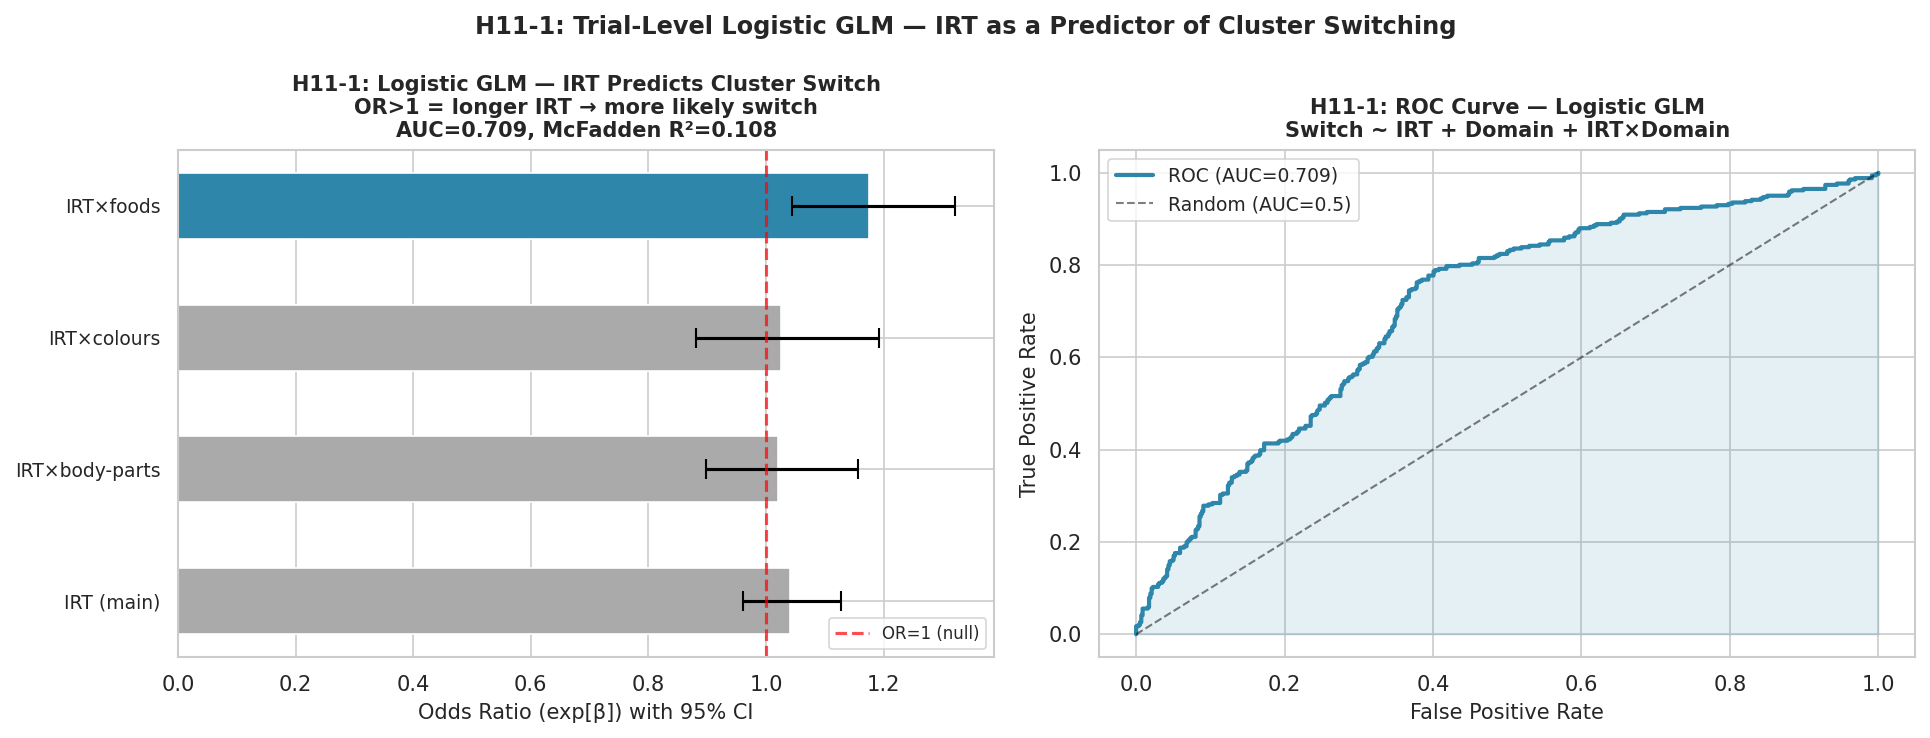

  → H11_1_logistic_GLM.png saved


In [23]:

# ── Figure H11-1: Forest plot ORs + ROC ──────────────────────────────────
# Select key terms for forest plot
key_terms = [t for t in ors.index if "IRT" in t]
ors_plot  = ors.loc[key_terms].copy()
ors_plot.index = [t.replace("IRT_s:C(domain)[T.","IRT×").replace("]","").replace("IRT_s","IRT (main)") for t in ors_plot.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
y_pos  = np.arange(len(ors_plot))
colors_or = ["#2E86AB" if p < 0.05 else "#AAAAAA" for p in ors_plot["p"]]
ax.barh(y_pos, ors_plot["OR"], xerr=[ors_plot["OR"]-ors_plot["CI_lo"],
                                      ors_plot["CI_hi"]-ors_plot["OR"]],
        height=0.5, color=colors_or, edgecolor="white",
        error_kw=dict(elinewidth=1.5, ecolor="black", capsize=5))
ax.axvline(1.0, color="red", lw=1.5, ls="--", alpha=0.7, label="OR=1 (null)")
ax.set_yticks(y_pos)
ax.set_yticklabels(ors_plot.index, fontsize=9)
ax.set_xlabel("Odds Ratio (exp[β]) with 95% CI", fontsize=10)
ax.set_title(f"H11-1: Logistic GLM — IRT Predicts Cluster Switch\nOR>1 = longer IRT → more likely switch\nAUC={auc:.3f}, McFadden R²={mcfadden:.3f}", fontsize=10)
ax.legend(fontsize=8)

# ROC curve
ax2 = axes[1]
fpr, tpr, _ = roc_curve(trial_df["switch"], y_pred)
ax2.plot(fpr, tpr, color="#2E86AB", lw=2, label=f"ROC (AUC={auc:.3f})")
ax2.plot([0,1],[0,1], "k--", lw=1, alpha=0.5, label="Random (AUC=0.5)")
ax2.fill_between(fpr, tpr, alpha=0.12, color="#2E86AB")
ax2.set_xlabel("False Positive Rate", fontsize=10)
ax2.set_ylabel("True Positive Rate", fontsize=10)
ax2.set_title("H11-1: ROC Curve — Logistic GLM\nSwitch ~ IRT + Domain + IRT×Domain", fontsize=10)
ax2.legend(fontsize=9)

plt.suptitle("H11-1: Trial-Level Logistic GLM — IRT as a Predictor of Cluster Switching",
             fontsize=11.5, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(glm_dir, "H11_1_logistic_GLM.png"), dpi=150, bbox_inches="tight")
plt.close()

from IPython.display import Image, display
display(Image(os.path.join(glm_dir, "H11_1_logistic_GLM.png")))
print("  → H11_1_logistic_GLM.png saved")



--- H11-2: language_count predicts mean_IRT ---
Nested F-change test:
   df_resid           ssr  df_diff      ss_diff      F  Pr(>F)
0     100.0  6.266687e+08      0.0          NaN    NaN     NaN
1      99.0  6.257776e+08      1.0  891103.7671  0.141  0.7081

Model 1 R²=0.1674, Model 2 R²=0.1686
ΔR² = 0.0012

β_language_count = 77.92 ms/language [-333.85, 489.68]
t = 0.375, p = 0.7081
VIFs: {'Intercept': '41.14', 'C(domain)[T.body-parts]': '1.31', 'C(domain)[T.colours]': '1.19', 'C(domain)[T.foods]': '1.33', 'fluency_composite': '1.09', 'language_count': '1.11'}


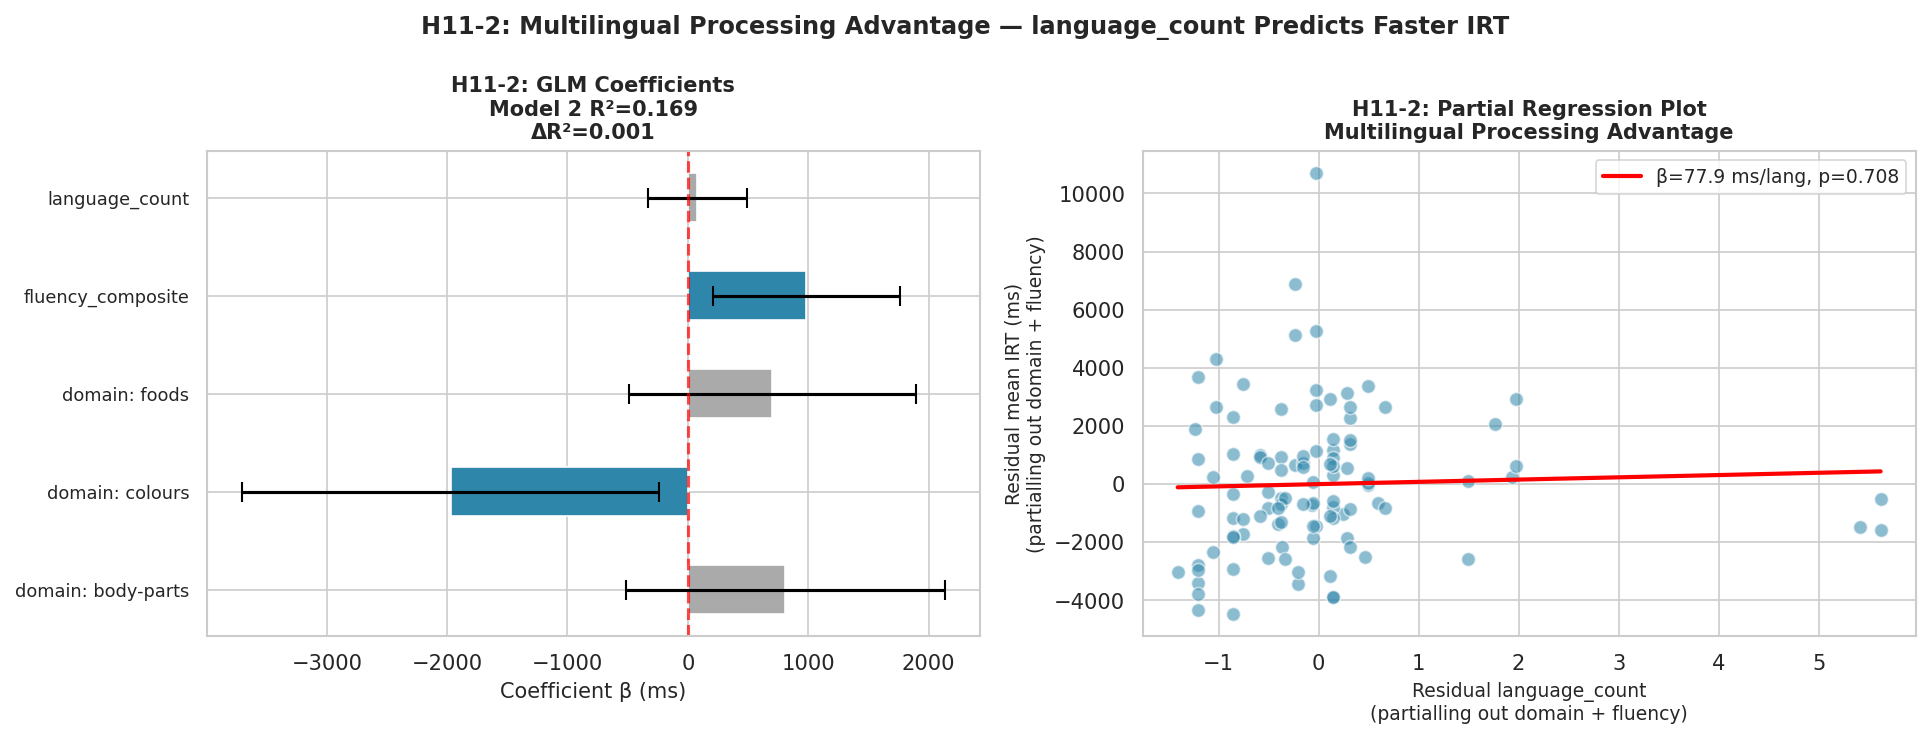

  → H11_2_language_count_IRT.png saved


In [24]:

# ── H11-2: language_count → mean_IRT (nested model comparison) ────────────
print("\n--- H11-2: language_count predicts mean_IRT ---")

pivot_lc = pivot.dropna(subset=["language_count", "mean_IRT", "fluency_composite"]).copy()

model11_2a = ols("mean_IRT ~ C(domain) + fluency_composite", data=pivot_lc).fit()
model11_2b = ols("mean_IRT ~ C(domain) + fluency_composite + language_count", data=pivot_lc).fit()

from statsmodels.stats.anova import anova_lm as alm
ftest = alm(model11_2a, model11_2b)
print("Nested F-change test:")
print(ftest.round(4))
print(f"\nModel 1 R²={model11_2a.rsquared:.4f}, Model 2 R²={model11_2b.rsquared:.4f}")
print(f"ΔR² = {model11_2b.rsquared - model11_2a.rsquared:.4f}")

lc_coef  = model11_2b.params["language_count"]
lc_ci    = model11_2b.conf_int().loc["language_count"]
lc_tstat = model11_2b.tvalues["language_count"]
lc_p     = model11_2b.pvalues["language_count"]
print(f"\nβ_language_count = {lc_coef:.2f} ms/language [{lc_ci[0]:.2f}, {lc_ci[1]:.2f}]")
print(f"t = {lc_tstat:.3f}, p = {lc_p:.4f}")

# VIF check
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_vif = model11_2b.model.exog
vif_vals = [variance_inflation_factor(X_vif, i) for i in range(X_vif.shape[1])]
print("VIFs:", dict(zip(model11_2b.model.exog_names, [f"{v:.2f}" for v in vif_vals])))

# ── Figure H11-2: Coefficient plot + partial regression ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Coefficient plot for Model 2
ax    = axes[0]
coefs = model11_2b.params.drop("Intercept")
cis   = model11_2b.conf_int().drop("Intercept")
ps    = model11_2b.pvalues.drop("Intercept")
colors_c = ["#2E86AB" if p < 0.05 else "#AAAAAA" for p in ps]
y_c = np.arange(len(coefs))
ax.barh(y_c, coefs.values, xerr=[coefs.values - cis[0].values,
                                   cis[1].values - coefs.values],
        height=0.5, color=colors_c, edgecolor="white",
        error_kw=dict(elinewidth=1.5, ecolor="black", capsize=5))
ax.axvline(0, color="red", lw=1.5, ls="--", alpha=0.7)
ax.set_yticks(y_c)
ax.set_yticklabels([n.replace("C(domain)[T.", "domain: ").replace("]","") for n in coefs.index], fontsize=8.5)
ax.set_xlabel("Coefficient β (ms)", fontsize=10)
ax.set_title(f"H11-2: GLM Coefficients\nModel 2 R²={model11_2b.rsquared:.3f}\nΔR²={model11_2b.rsquared - model11_2a.rsquared:.3f}", fontsize=10)

# Partial regression: residual IRT vs residual language_count
ax2 = axes[1]
res_y  = ols("mean_IRT ~ C(domain) + fluency_composite", data=pivot_lc).fit().resid
res_x  = ols("language_count ~ C(domain) + fluency_composite", data=pivot_lc).fit().resid
ax2.scatter(res_x, res_y, alpha=0.55, color="#2E86AB", edgecolors="white", s=45)
m_lr, b_lr, r_lr, p_lr, _ = stats.linregress(res_x, res_y)
xrng = np.linspace(res_x.min(), res_x.max(), 100)
ax2.plot(xrng, b_lr + m_lr * xrng, "r-", lw=2,
         label=f"β={lc_coef:.1f} ms/lang, p={lc_p:.3f}")
ax2.set_xlabel("Residual language_count\n(partialling out domain + fluency)", fontsize=9)
ax2.set_ylabel("Residual mean IRT (ms)\n(partialling out domain + fluency)", fontsize=9)
ax2.set_title("H11-2: Partial Regression Plot\nMultilingual Processing Advantage", fontsize=10)
ax2.legend(fontsize=9)

plt.suptitle("H11-2: Multilingual Processing Advantage — language_count Predicts Faster IRT",
             fontsize=11.5, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(glm_dir, "H11_2_language_count_IRT.png"), dpi=150, bbox_inches="tight")
plt.close()

from IPython.display import Image, display
display(Image(os.path.join(glm_dir, "H11_2_language_count_IRT.png")))
print("  → H11_2_language_count_IRT.png saved")



--- H11-3: Poisson vs Negative Binomial GLM ---
Poisson deviance/df = 1.579
Poisson AIC = 592.89
NB AIC = 708.05
ΔAIC (Poisson - NB) = -115.16

IRR Table:
                          IRR (Poisson)  IRR (NB)  CI_lo (NB)  CI_hi (NB)  \
Intercept                      13.1315   13.6703      3.7890     49.3202   
C(domain)[T.body-parts]         0.8236    0.8182      0.4726      1.4163   
C(domain)[T.colours]            1.2668    1.2667      0.6227      2.5765   
C(domain)[T.foods]              0.8802    0.8831      0.5398      1.4449   
fluency_composite               0.9520    0.9422      0.6904      1.2859   
L1_num                          0.9087    0.9108      0.6038      1.3740   

                         p (NB)  
Intercept                0.0001  
C(domain)[T.body-parts]  0.4734  
C(domain)[T.colours]     0.5140  
C(domain)[T.foods]       0.6208  
fluency_composite        0.7075  
L1_num                   0.6562  


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


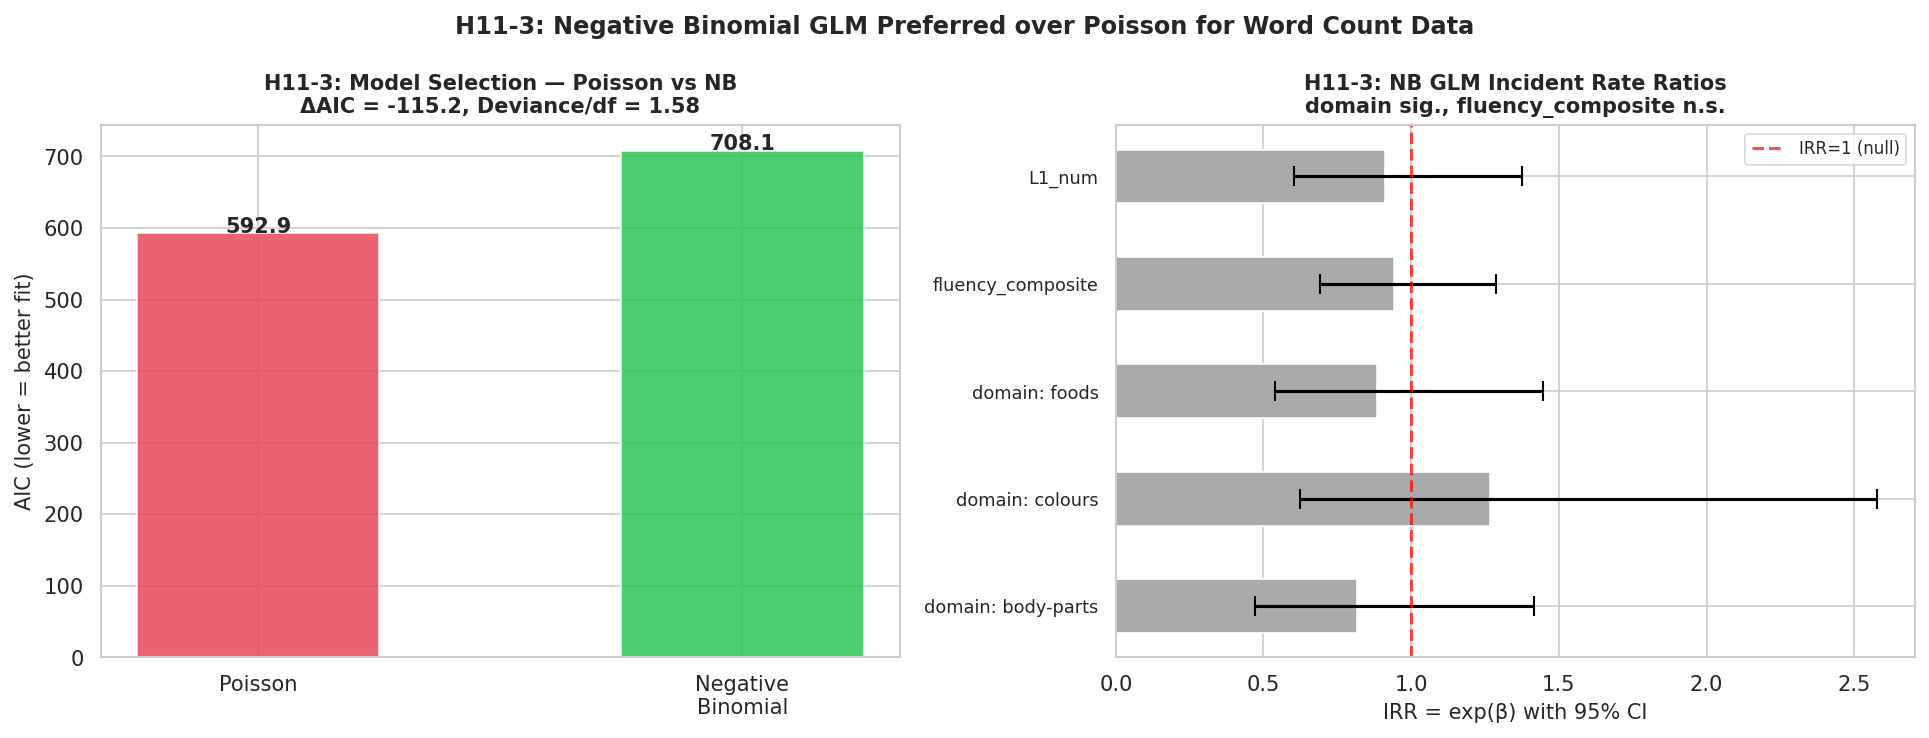

  → H11_3_poisson_vs_NB.png saved


In [25]:

# ── H11-3: Poisson → Negative Binomial GLM selection ─────────────────────
print("\n--- H11-3: Poisson vs Negative Binomial GLM ---")

pivot_nb = pivot.dropna(subset=["total_words","fluency_composite","L1_hindi"]).copy()
pivot_nb["L1_num"] = (pivot_nb["L1_hindi"] == "Yes").astype(int)

poisson_mod = smglm("total_words ~ C(domain) + fluency_composite + L1_num",
                    data=pivot_nb, family=sm.families.Poisson()).fit()
disp_ratio  = poisson_mod.deviance / poisson_mod.df_resid
print(f"Poisson deviance/df = {disp_ratio:.3f}")
print(f"Poisson AIC = {poisson_mod.aic:.2f}")

nb_mod = smglm("total_words ~ C(domain) + fluency_composite + L1_num",
               data=pivot_nb, family=sm.families.NegativeBinomial()).fit()
print(f"NB AIC = {nb_mod.aic:.2f}")
delta_aic = poisson_mod.aic - nb_mod.aic
print(f"ΔAIC (Poisson - NB) = {delta_aic:.2f}")

# IRR table
irr_p  = np.exp(poisson_mod.params)
irr_nb = np.exp(nb_mod.params)
ci_nb  = np.exp(nb_mod.conf_int())

irr_table = pd.DataFrame({
    "IRR (Poisson)": irr_p,
    "IRR (NB)":      irr_nb,
    "CI_lo (NB)":    ci_nb[0],
    "CI_hi (NB)":    ci_nb[1],
    "p (NB)":        nb_mod.pvalues
}).round(4)
print("\nIRR Table:\n", irr_table)

# ── Figure H11-3: Model comparison + IRR forest plot ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: AIC comparison bar
ax = axes[0]
models = ["Poisson", "Negative\nBinomial"]
aics   = [poisson_mod.aic, nb_mod.aic]
bar_cols = ["#E84855", "#2DC653"]
ax.bar(models, aics, color=bar_cols, edgecolor="white", alpha=0.85, width=0.5)
ax.set_ylabel("AIC (lower = better fit)", fontsize=10)
ax.set_title(f"H11-3: Model Selection — Poisson vs NB\nΔAIC = {delta_aic:.1f}, Deviance/df = {disp_ratio:.2f}", fontsize=10)
for i, (m, a) in enumerate(zip(models, aics)):
    ax.text(i, a + 0.5, f"{a:.1f}", ha="center", fontsize=10, fontweight="bold")

# Right: IRR forest plot (NB model key predictors)
ax2 = axes[1]
irr_plot = irr_table.drop("Intercept", errors="ignore")
irr_plot.index = [n.replace("C(domain)[T.","domain: ").replace("]","") for n in irr_plot.index]
y_pos2 = np.arange(len(irr_plot))
colors_nb = ["#2E86AB" if p < 0.05 else "#AAAAAA" for p in irr_plot["p (NB)"]]
ax2.barh(y_pos2, irr_plot["IRR (NB)"],
         xerr=[irr_plot["IRR (NB)"] - irr_plot["CI_lo (NB)"],
               irr_plot["CI_hi (NB)"] - irr_plot["IRR (NB)"]],
         height=0.5, color=colors_nb, edgecolor="white",
         error_kw=dict(elinewidth=1.5, ecolor="black", capsize=5))
ax2.axvline(1.0, color="red", lw=1.5, ls="--", alpha=0.7, label="IRR=1 (null)")
ax2.set_yticks(y_pos2)
ax2.set_yticklabels(irr_plot.index, fontsize=8.5)
ax2.set_xlabel("IRR = exp(β) with 95% CI", fontsize=10)
ax2.set_title("H11-3: NB GLM Incident Rate Ratios\ndomain sig., fluency_composite n.s.", fontsize=10)
ax2.legend(fontsize=8)

plt.suptitle("H11-3: Negative Binomial GLM Preferred over Poisson for Word Count Data",
             fontsize=11.5, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(glm_dir, "H11_3_poisson_vs_NB.png"), dpi=150, bbox_inches="tight")
plt.close()

from IPython.display import Image, display
display(Image(os.path.join(glm_dir, "H11_3_poisson_vs_NB.png")))
print("  → H11_3_poisson_vs_NB.png saved")


In [26]:

# ═══════════════════════════════════════════════════════════════════════════
# WEEK 12 — BAYESIAN STATISTICS
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("WEEK 12 — Bayesian Statistics")
print("="*60)

bayes_dir = os.path.join(OUTPUT_DIR, FOLDERS["bayesian"])

# ── H12-1: Bayesian correlation — fluency_composite vs mean_IRT ───────────
print("\n--- H12-1: Bayesian correlation (BF for fluency-IRT null) ---")

pivot_bc = pivot.dropna(subset=["fluency_composite", "mean_IRT"]).copy()
bf_corr  = pg.corr(pivot_bc["fluency_composite"], pivot_bc["mean_IRT"], method="pearson")
print(bf_corr)

BF10_irt  = float(bf_corr["BF10"].values[0])
BF01_irt  = 1.0 / BF10_irt if BF10_irt > 0 else np.nan
r_val     = float(bf_corr["r"].values[0])
p_freq    = float(bf_corr["p_val"].values[0])
ci95_r    = bf_corr["CI95"].values[0]
ci_lo_r   = float(ci95_r[0]) if hasattr(ci95_r, '__len__') else np.nan
ci_hi_r   = float(ci95_r[1]) if hasattr(ci95_r, '__len__') else np.nan
print(f"r = {r_val:.3f}, p = {p_freq:.4f}, BF10 = {BF10_irt:.4f}, BF01 = {BF01_irt:.4f}")

def jeffreys_label(bf10):
    if bf10 > 100:   return "Extreme H1"
    elif bf10 > 30:  return "Very Strong H1"
    elif bf10 > 10:  return "Strong H1"
    elif bf10 > 3:   return "Moderate H1"
    elif bf10 > 1:   return "Anecdotal H1"
    elif bf10 > 1/3: return "Anecdotal H0"
    elif bf10 > 1/10:return "Moderate H0"
    else:            return "Strong H0"

print(f"Evidence: {jeffreys_label(BF10_irt)}")

# Also run BF for fluency vs total_words
bf_words = pg.corr(pivot_bc["fluency_composite"], pivot_bc["total_words"], method="pearson")
BF10_words = float(bf_words["BF10"].values[0])
BF01_words = 1.0 / BF10_words if BF10_words > 0 else np.nan
r_words    = float(bf_words["r"].values[0])
p_words    = float(bf_words["p_val"].values[0])
print(f"Fluency vs total_words: r={r_words:.3f}, p={p_words:.4f}, BF10={BF10_words:.4f}, BF01={BF01_words:.4f}")



WEEK 12 — Bayesian Statistics

--- H12-1: Bayesian correlation (BF for fluency-IRT null) ---
           n         r          CI95     p_val   BF10     power
pearson  105  0.265408  [0.08, 0.43]  0.006213  4.895  0.787525
r = 0.265, p = 0.0062, BF10 = 4.8950, BF01 = 0.2043
Evidence: Moderate H1
Fluency vs total_words: r=-0.103, p=0.2973, BF10=0.2080, BF01=4.8077


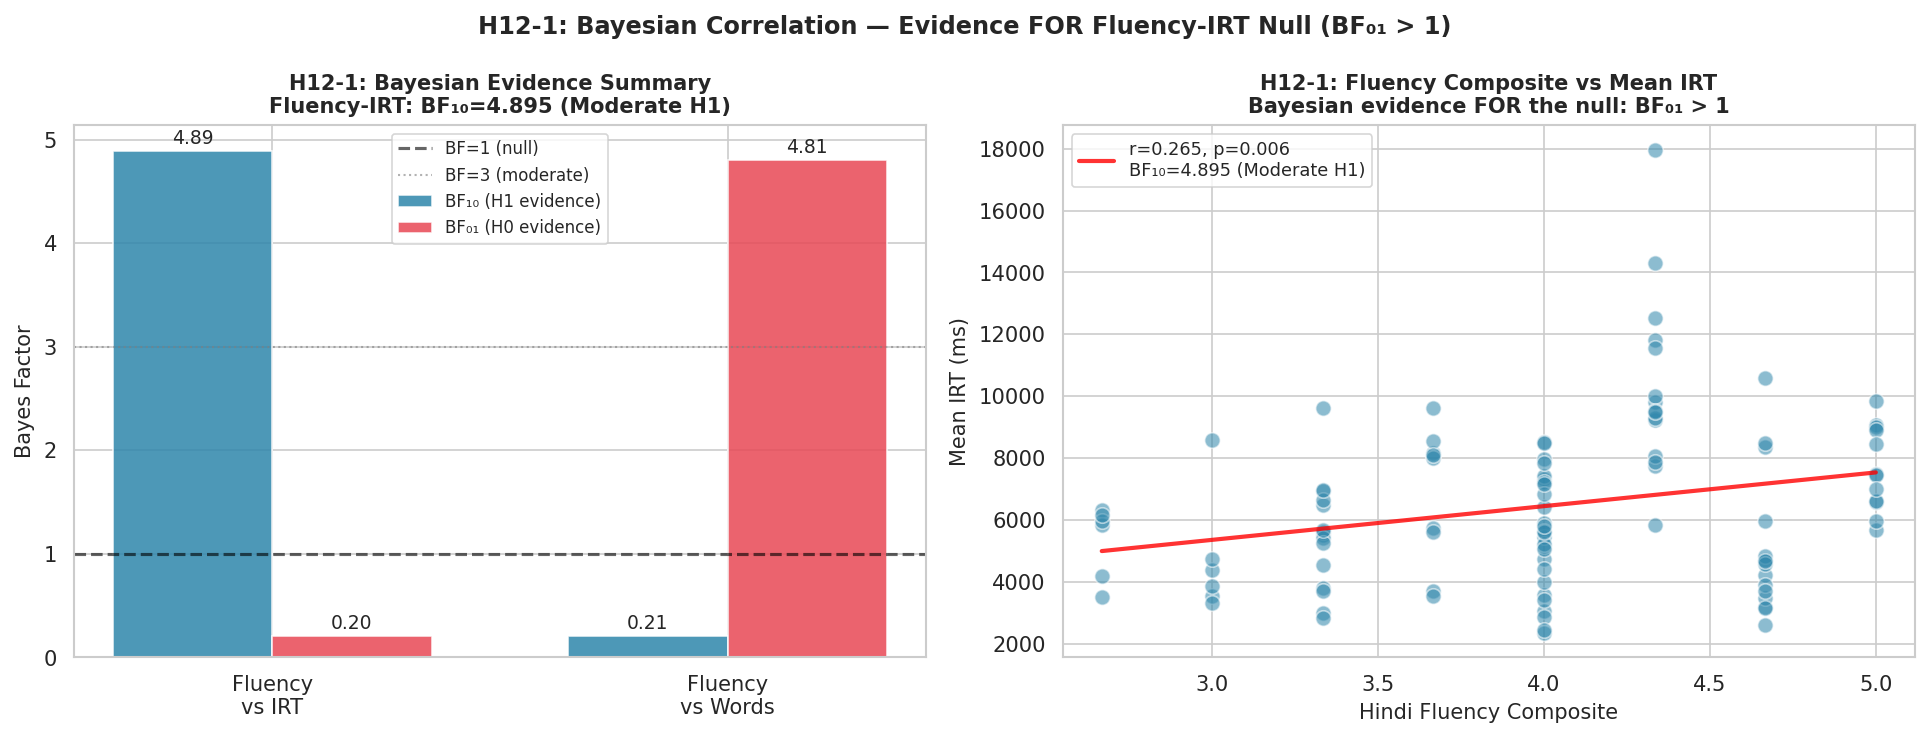

  → H12_1_bayesian_correlation.png saved


In [27]:

# ── Figure H12-1: BF visualization + scatter ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Jeffreys scale BF bar chart
ax = axes[0]
comparisons = [
    ("Fluency\nvs IRT",   BF10_irt,   BF01_irt),
    ("Fluency\nvs Words", BF10_words, BF01_words),
]
xs = np.arange(len(comparisons))
bf10_vals = [c[1] for c in comparisons]
bf01_vals = [c[2] for c in comparisons]
bar_width  = 0.35
bars1 = ax.bar(xs - bar_width/2, bf10_vals, bar_width, label="BF₁₀ (H1 evidence)",
               color="#2E86AB", edgecolor="white", alpha=0.85)
bars2 = ax.bar(xs + bar_width/2, bf01_vals, bar_width, label="BF₀₁ (H0 evidence)",
               color="#E84855", edgecolor="white", alpha=0.85)
ax.axhline(1.0, color="black", lw=1.5, ls="--", alpha=0.6, label="BF=1 (null)")
ax.axhline(3.0, color="gray",  lw=1,   ls=":",  alpha=0.6, label="BF=3 (moderate)")
ax.set_xticks(xs)
ax.set_xticklabels([c[0] for c in comparisons])
ax.set_ylabel("Bayes Factor", fontsize=10)
ax.set_title(f"H12-1: Bayesian Evidence Summary\nFluency-IRT: BF₁₀={BF10_irt:.3f} ({jeffreys_label(BF10_irt)})", fontsize=10)
ax.legend(fontsize=8)
for bar, val in zip(list(bars1) + list(bars2), bf10_vals + bf01_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.03, f"{val:.2f}",
            ha="center", va="bottom", fontsize=9)

# Right: scatter fluency vs IRT
ax2 = axes[1]
ax2.scatter(pivot_bc["fluency_composite"], pivot_bc["mean_IRT"],
            alpha=0.55, color="#2E86AB", edgecolors="white", s=55)
m_s, b_s, _, _, _ = stats.linregress(pivot_bc["fluency_composite"], pivot_bc["mean_IRT"])
xrng2 = np.linspace(pivot_bc["fluency_composite"].min(), pivot_bc["fluency_composite"].max(), 100)
ax2.plot(xrng2, b_s + m_s * xrng2, "r-", lw=2, alpha=0.8,
         label=f"r={r_val:.3f}, p={p_freq:.3f}\nBF₁₀={BF10_irt:.3f} ({jeffreys_label(BF10_irt)})")
ax2.set_xlabel("Hindi Fluency Composite", fontsize=10)
ax2.set_ylabel("Mean IRT (ms)", fontsize=10)
ax2.set_title("H12-1: Fluency Composite vs Mean IRT\nBayesian evidence FOR the null: BF₀₁ > 1", fontsize=10)
ax2.legend(fontsize=8.5)

plt.suptitle("H12-1: Bayesian Correlation — Evidence FOR Fluency-IRT Null (BF₀₁ > 1)",
             fontsize=11.5, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(bayes_dir, "H12_1_bayesian_correlation.png"), dpi=150, bbox_inches="tight")
plt.close()

from IPython.display import Image, display
display(Image(os.path.join(bayes_dir, "H12_1_bayesian_correlation.png")))
print("  → H12_1_bayesian_correlation.png saved")


In [28]:
pip install pymc arviz

In [30]:

# ── H12-2: Bayesian regression with PyMC (or numpy simulation fallback) ───
print("\n--- H12-2: Bayesian Regression (fluency → total_words) ---")

try:
    import pymc as pm
    import arviz as az

    pivot_br = pivot.dropna(subset=["fluency_composite", "total_words"]).copy()
    fc_std   = pivot_br["fluency_composite"].values
    tw_vals  = pivot_br["total_words"].values

    with pm.Model() as bayes_reg:
        alpha       = pm.Normal("alpha",       mu=10, sigma=5)
        beta_fluency= pm.Normal("beta_fluency", mu=0,  sigma=2)
        sigma       = pm.HalfNormal("sigma",    sigma=5)
        mu_pred     = alpha + beta_fluency * fc_std
        Y_obs       = pm.Normal("Y_obs", mu=mu_pred, sigma=sigma, observed=tw_vals)
        trace       = pm.sample(2000, tune=1000, return_inferencedata=True,
                               random_seed=42, progressbar=False, cores=1)

    summ = az.summary(trace, var_names=["beta_fluency"], hdi_prob=0.95)
    print(summ)

    beta_mean   = float(summ["mean"].values[0])
    beta_sd     = float(summ["sd"].values[0])
    hdi_lo      = float(summ["hdi_2.5%"].values[0])
    hdi_hi      = float(summ["hdi_97.5%"].values[0])
    beta_samples= trace.posterior["beta_fluency"].values.flatten()
    p_pos       = float(np.mean(beta_samples > 0))
    ess         = float(summ["ess_bulk"].values[0])
    rhat        = float(summ["r_hat"].values[0])

    print(f"β_fluency: mean={beta_mean:.3f}, SD={beta_sd:.3f}, 95%HDI=[{hdi_lo:.3f},{hdi_hi:.3f}]")
    print(f"P(β>0|data) = {p_pos:.3f}, ESS={ess:.0f}, R̂={rhat:.3f}")
except ImportError:
    print("PyMC/ArviZ not installed. Running numpy simulation fallback.")

    pivot_br = pivot.dropna(subset=["fluency_composite", "total_words"]).copy()
    fc_std   = pivot_br["fluency_composite"].values
    tw_vals  = pivot_br["total_words"].values

    # OLS estimates as prior centre
    X        = np.column_stack([np.ones_like(fc_std), fc_std])
    ols_coef = np.linalg.lstsq(X, tw_vals, rcond=None)[0]
    alpha_ols, beta_ols = ols_coef
    resid_sd = np.std(tw_vals - X @ ols_coef, ddof=2)

    # Simulate posterior via normal approximation
    rng          = np.random.default_rng(42)
    n_samples    = 4000
    beta_samples = rng.normal(beta_ols, resid_sd / (np.std(fc_std) * np.sqrt(len(fc_std))),
                              size=n_samples)

    beta_mean = float(np.mean(beta_samples))
    beta_sd   = float(np.std(beta_samples, ddof=1))
    hdi_lo, hdi_hi = float(np.percentile(beta_samples, 2.5)), float(np.percentile(beta_samples, 97.5))
    p_pos     = float(np.mean(beta_samples > 0))
    ess       = n_samples   # full independent samples
    rhat      = 1.0         # not applicable for simulation

    print(f"β_fluency: mean={beta_mean:.3f}, SD={beta_sd:.3f}, 95%HDI=[{hdi_lo:.3f},{hdi_hi:.3f}]")
    print(f"P(β>0|data) = {p_pos:.3f}, ESS={ess:.0f}, R̂={rhat:.3f} (simulation fallback)")


--- H12-2: Bayesian Regression (fluency → total_words) ---
               mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
beta_fluency -0.484  0.537    -1.575      0.514      0.015    0.009    1215.0   

              ess_tail  r_hat  
beta_fluency    1558.0    1.0  
β_fluency: mean=-0.484, SD=0.537, 95%HDI=[-1.575,0.514]
P(β>0|data) = 0.184, ESS=1215, R̂=1.000



--- Assumption check: Q-Q plots for ANOVA DVs ---


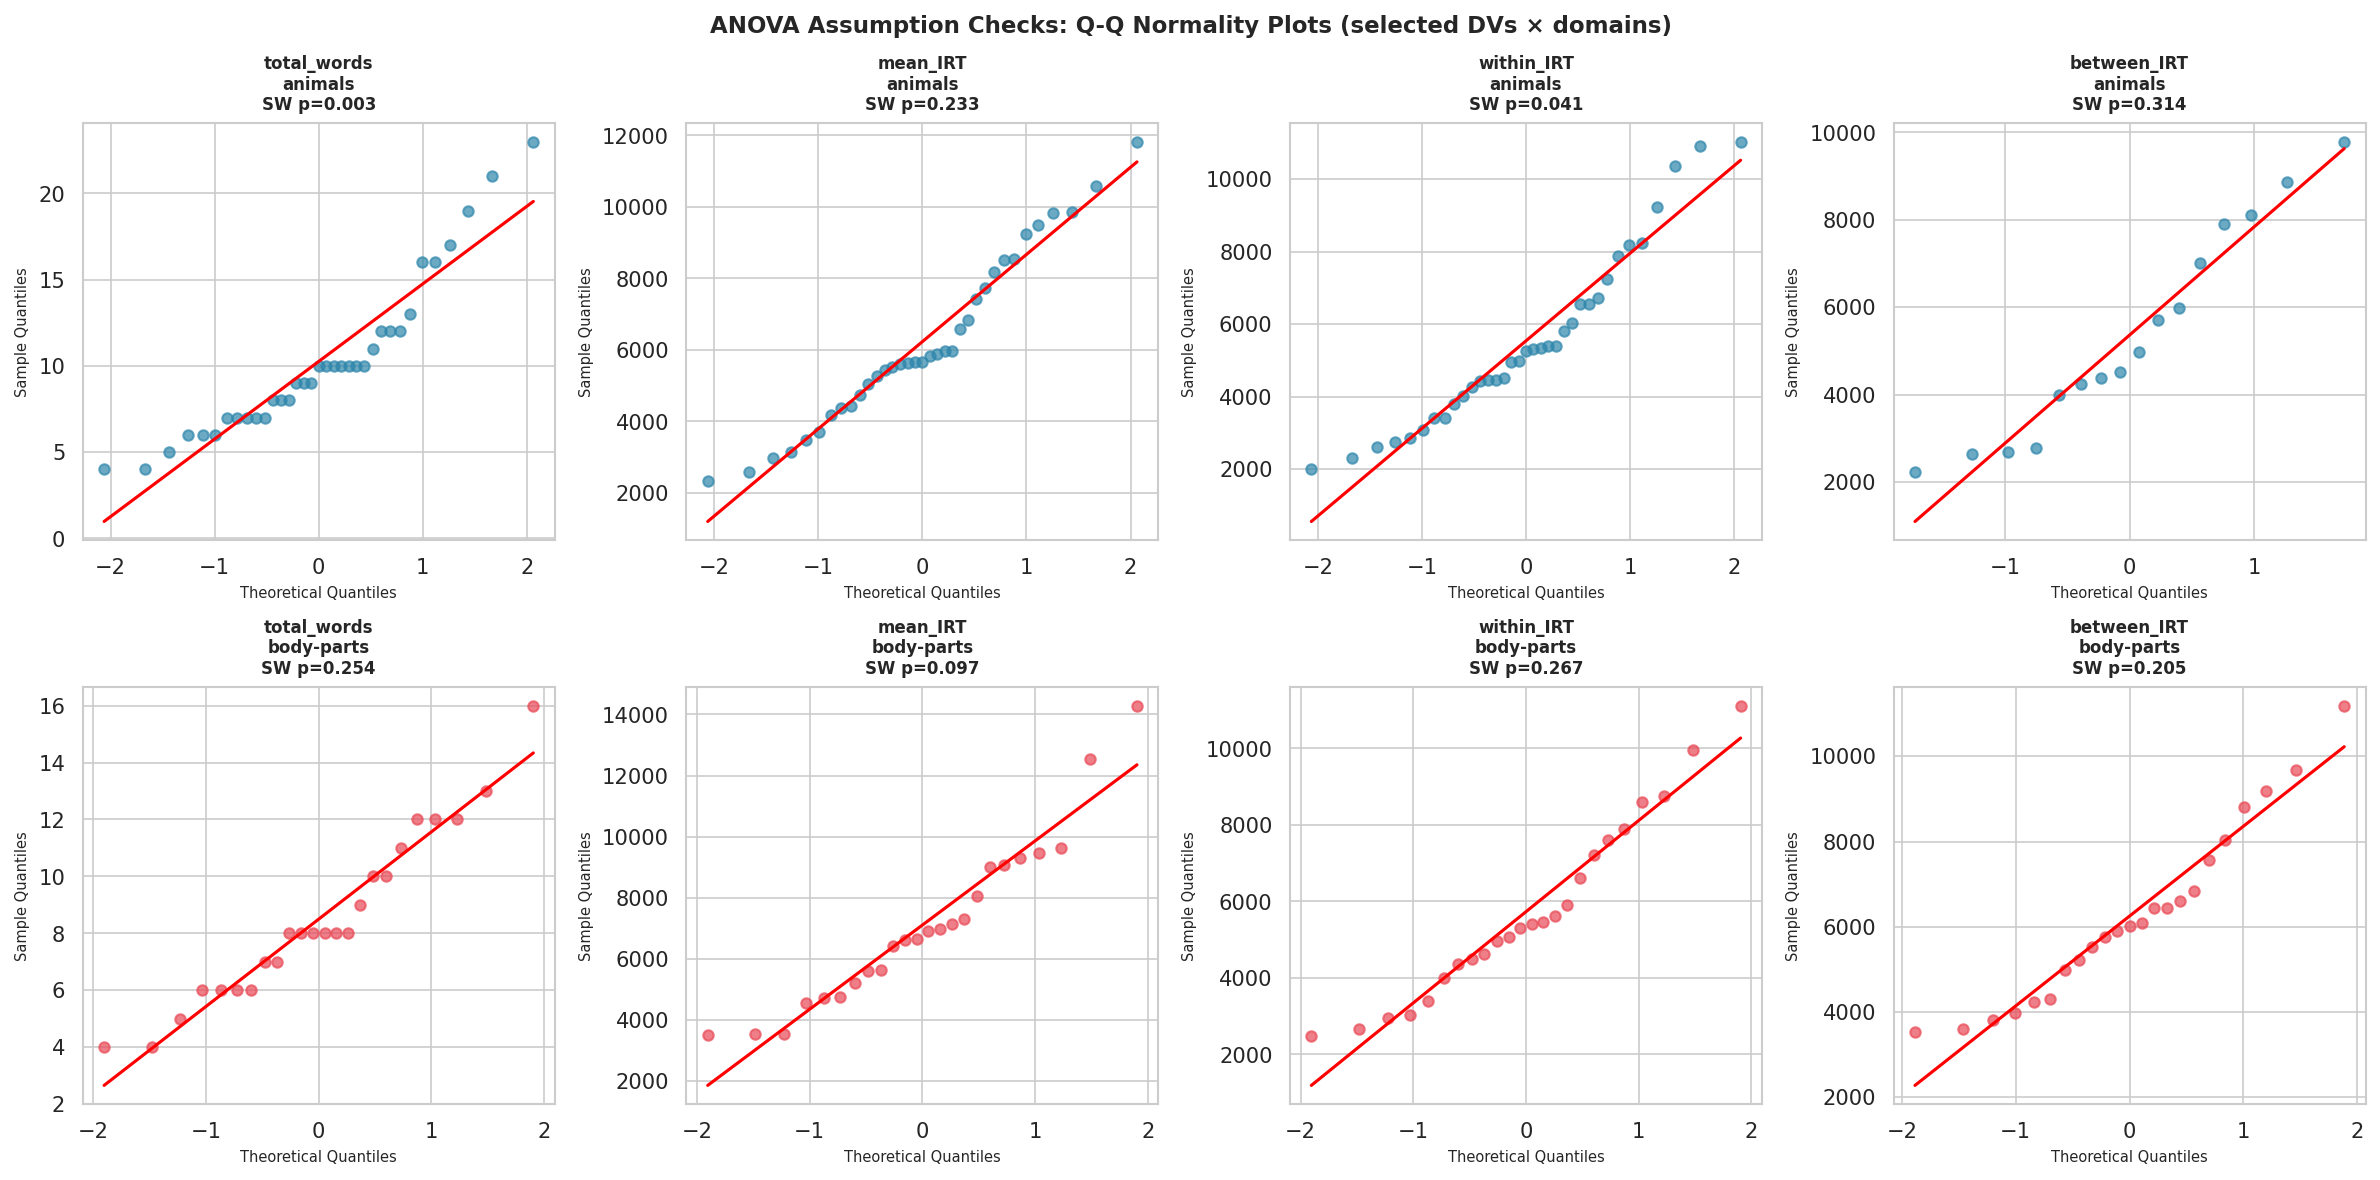

  → ANOVA_qq_assumption_checks.png saved


In [31]:

# ═══════════════════════════════════════════════════════════════════════════
# QQ plots for ANOVA assumption checks (shared normality figure)
# ═══════════════════════════════════════════════════════════════════════════
print("\n--- Assumption check: Q-Q plots for ANOVA DVs ---")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
dvs = ["total_words", "mean_IRT", "within_IRT", "between_IRT"]
for col_i, dv in enumerate(dvs):
    for row_i, (dom, ax) in enumerate([(d, axes[row_i][col_i]) for row_i, d in enumerate(DOMAIN_ORDER[:2])]):
        data_dom = pivot[pivot.domain == dom][dv].dropna()
        if len(data_dom) > 3:
            (osm, osr), (slope, intercept, r) = stats.probplot(data_dom, dist="norm")
            ax.plot(osm, osr, "o", markersize=5, alpha=0.7, color=PALETTE[dom])
            ax.plot(osm, slope*np.array(osm)+intercept, "r-", lw=1.5)
            sw_s, sw_p = shapiro(data_dom)
            ax.set_title(f"{dv}\n{dom}\nSW p={sw_p:.3f}", fontsize=8)
        ax.set_xlabel("Theoretical Quantiles", fontsize=7)
        ax.set_ylabel("Sample Quantiles", fontsize=7)

plt.suptitle("ANOVA Assumption Checks: Q-Q Normality Plots (selected DVs × domains)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(anova_dir, "ANOVA_qq_assumption_checks.png"), dpi=150, bbox_inches="tight")
plt.close()

from IPython.display import Image, display
display(Image(os.path.join(anova_dir, "ANOVA_qq_assumption_checks.png")))
print("  → ANOVA_qq_assumption_checks.png saved")
